In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

In [2]:
data_df = pd.read_excel("burndata.xlsx", sheet_name="data")
print(f"Shape: {data_df.shape}  ({data_df.shape[0]} rows, {data_df.shape[1]} columns)")

Shape: (635, 23)  (635 rows, 23 columns)


In [3]:
print(f"Total hospitals: {len(data_df)}")
print()
print("Missing values per column:")
print(data_df.isna().sum())

Total hospitals: 635

Missing values per column:
STATE_FULL               0
STATE                    0
COUNTY                   0
ADDRESS                  0
CITY                     0
ZIP_CODE                 0
AHA_ID                   1
HOSPITAL_NAME            0
TOTAL_BEDS               0
BURN_BEDS              505
TRAUMA_ADULT            70
TRAUMA_PEDS            489
BURN_ADULT             515
BURN_PEDS              546
ACS_VERIFIED            18
ADULT_TRAUMA_L1        406
ADULT_TRAUMA_L2        299
PEDS_TRAUMA_L1         555
PEDS_TRAUMA_L2         569
ABA_VERIFIED           492
TC_STATE_DESIGNATED     18
BC_STATE_DESIGNATED    533
PHONE                    0
dtype: int64


In [5]:
#Strip whitespace
str_flag_cols = ['ABA_VERIFIED', 'ACS_VERIFIED', 'TC_STATE_DESIGNATED', 'BC_STATE_DESIGNATED']
for col in str_flag_cols:
    data_df[col] = data_df[col].astype(str).str.strip().replace('nan', np.nan)

#Convert float to integers
int_flag_cols = [
    'BURN_ADULT', 'BURN_PEDS',
    'TRAUMA_ADULT', 'TRAUMA_PEDS',
    'ADULT_TRAUMA_L1', 'ADULT_TRAUMA_L2',
    'PEDS_TRAUMA_L1', 'PEDS_TRAUMA_L2'
]
for col in int_flag_cols:
    data_df[col] = data_df[col].fillna(0).astype(int)

#Standardise ZIP
data_df['ZIP_CODE'] = (
    data_df['ZIP_CODE']
    .astype(str)
    .str.replace('.0', '', regex=False)
    .str.strip()
    .str.zfill(5)
)

#Re-derive TRAUMA_ADULT and TRAUMA_PEDS from level columns
# Froedtert Hospital had ADULT_TRAUMA_L1=1 but TRAUMA_ADULT was blank
data_df['TRAUMA_ADULT'] = ((data_df['ADULT_TRAUMA_L1'] == 1) | (data_df['ADULT_TRAUMA_L2'] == 1)).astype(int)
data_df['TRAUMA_PEDS']  = ((data_df['PEDS_TRAUMA_L1']  == 1) | (data_df['PEDS_TRAUMA_L2']  == 1)).astype(int)


In [6]:
# Capability flags
data_df['is_burn']        = (data_df['BURN_ADULT'] == 1) | (data_df['BURN_PEDS'] == 1)
data_df['is_trauma']      = (data_df['TRAUMA_ADULT'] == 1) | (data_df['TRAUMA_PEDS'] == 1)
data_df['is_trauma_only'] = data_df['is_trauma'] & ~data_df['is_burn']
data_df['is_burn_only']   = data_df['is_burn']   & ~data_df['is_trauma']
data_df['is_both']        = data_df['is_burn']   &  data_df['is_trauma']

# Pediatric flags
data_df['is_burn_peds']       = data_df['BURN_PEDS'] == 1
data_df['is_burn_adult_only'] = (data_df['BURN_ADULT'] == 1) & (data_df['BURN_PEDS'] == 0)

# Trauma level flags
data_df['is_l1_trauma'] = (data_df['ADULT_TRAUMA_L1'] == 1) | (data_df['PEDS_TRAUMA_L1'] == 1)
data_df['is_l2_trauma'] = (data_df['ADULT_TRAUMA_L2'] == 1) | (data_df['PEDS_TRAUMA_L2'] == 1)

# Verification flags
data_df['is_aba_verified']   = data_df['ABA_VERIFIED']        == 'Yes'
data_df['is_acs_verified']   = data_df['ACS_VERIFIED']        == 'Yes'
data_df['is_bc_state_desig'] = data_df['BC_STATE_DESIGNATED'] == 'Yes'

# Verification tier (4 tiers based on data dictionary)
# Tier 1: ABA + State designated
# Tier 2: ABA only
# Tier 3: State designated only
# Tier 4: No designation at all
def assign_verification_tier(row):
    if not row['is_burn']:
        return 'Not a burn center'
    aba   = row['is_aba_verified']
    state = row['is_bc_state_desig']
    if aba and state:   return 'Tier 1 — ABA + State'
    elif aba:           return 'Tier 2 — ABA only'
    elif state:         return 'Tier 3 — State only'
    else:               return 'Tier 4 — No designation'

data_df['verification_tier'] = data_df.apply(assign_verification_tier, axis=1)

# Nationally verified = Tier 1 + Tier 2 (ABA verified regardless of state designation)
data_df['is_nationally_verified'] = data_df['verification_tier'].isin([
    'Tier 1 — ABA + State',
    'Tier 2 — ABA only'
])

print('=== Capability ===')
print(f'  is_burn:               {data_df["is_burn"].sum():>4}')
print(f'  is_trauma:             {data_df["is_trauma"].sum():>4}')
print(f'  is_trauma_only:        {data_df["is_trauma_only"].sum():>4}  referral bottlenecks')
print(f'  is_burn_only:          {data_df["is_burn_only"].sum():>4}')
print(f'  is_both:               {data_df["is_both"].sum():>4}')
print()
print('=== Pediatric ===')
print(f'  is_burn_peds:          {data_df["is_burn_peds"].sum():>4}')
print(f'  is_burn_adult_only:    {data_df["is_burn_adult_only"].sum():>4}')
print()
print('=== Trauma level ===')
print(f'  is_l1_trauma:          {data_df["is_l1_trauma"].sum():>4}')
print(f'  is_l2_trauma:          {data_df["is_l2_trauma"].sum():>4}')
print()
print('=== Verification ===')
print(f'  is_nationally_verified:{data_df["is_nationally_verified"].sum():>4}  (Tier 1+2, ABA verified)')
burn_only = data_df[data_df['is_burn']]
for tier in ['Tier 1 — ABA + State','Tier 2 — ABA only','Tier 3 — State only','Tier 4 — No designation']:
    n = (burn_only['verification_tier'] == tier).sum()
    print(f'  {tier:<28} {n:>3}  ({n/len(burn_only)*100:.0f}%)')

=== Capability ===
  is_burn:                136
  is_trauma:              617
  is_trauma_only:         499  referral bottlenecks
  is_burn_only:            18
  is_both:                118

=== Pediatric ===
  is_burn_peds:            89
  is_burn_adult_only:      47

=== Trauma level ===
  is_l1_trauma:           270
  is_l2_trauma:           387

=== Verification ===
  is_nationally_verified:  76  (Tier 1+2, ABA verified)
  Tier 1 — ABA + State          37  (27%)
  Tier 2 — ABA only             39  (29%)
  Tier 3 — State only           21  (15%)
  Tier 4 — No designation       39  (29%)


In [7]:
burn_centers   = data_df[data_df['is_burn']].copy()
missing_beds   = burn_centers[burn_centers['BURN_BEDS'].isna()]
burn_with_beds = burn_centers.dropna(subset=['BURN_BEDS'])
burn_centers['beds_known'] = burn_centers['BURN_BEDS'].notna()

print(f'Total burn centers:              {len(burn_centers)}')
print(f'With known bed count:            {len(burn_with_beds)}')
print(f'Unknown bed count:               {len(missing_beds)}')
print('The 6 with unknown bed counts:')
print(missing_beds[['HOSPITAL_NAME', 'STATE', 'ABA_VERIFIED', 'TOTAL_BEDS']].to_string(index=False))

Total burn centers:              136
With known bed count:            130
Unknown bed count:               6

The 6 with unknown bed counts:
                                                                          HOSPITAL_NAME STATE ABA_VERIFIED  TOTAL_BEDS
                                          Jackson Memorial Hospital (Miami Burn Center)    FL          Yes        1550
                                            Grady Memorial Hospital (Grady Burn Center)    GA          Yes         961
                           Johns Hopkins Hospital (Johns Hopkins Pediatric Burn Center)    MD          Yes        1091
Thomas Jefferson University Hospital (Thomas Jefferson University Hospital Burn Center)    PA           No         926
            Rhode Island Hospital/Hasbro Children's Hospital (Rhode Island Burn Center)    RI          Yes         719
                                            University Hospital (Pediatric Burn Center)    TX           No         700


In [8]:
# Counting questions  -> use all 136
total_burn_centers = len(burn_centers)
nationally_verified_count = burn_centers['is_nationally_verified'].sum()
states_with_burn   = burn_centers['STATE'].nunique()

# Capacity questions -> use only 130 with known counts
total_burn_beds  = int(burn_with_beds['BURN_BEDS'].sum())
avg_burn_beds    = burn_with_beds['BURN_BEDS'].mean()
median_burn_beds = burn_with_beds['BURN_BEDS'].median()

print(f'Total burn centers:              {total_burn_centers}')
print(f'Nationally verified (Tier 1+2):  {nationally_verified_count}')
print(f'States with burn coverage:       {states_with_burn}')
print(f'Total burn beds (130 centers):   {total_burn_beds}')
print(f'Average beds per center:         {avg_burn_beds:.1f}')
print(f'Median beds per center:          {median_burn_beds:.0f}')

Total burn centers:              136
Nationally verified (Tier 1+2):  76
States with burn coverage:       43
Total burn beds (130 centers):   2080
Average beds per center:         16.0
Median beds per center:          14


In [9]:
# Geographic gaps

state_burn_summary = (
    data_df
    .groupby('STATE')
    .agg(
        total_hospitals  = ('HOSPITAL_NAME',          'count'),
        burn_centers     = ('is_burn',                 'sum'),
        nationally_verif = ('is_nationally_verified',  'sum'),
        trauma_only      = ('is_trauma_only',          'sum'),
        l1_trauma        = ('is_l1_trauma',            'sum'),
    )
    .reset_index()
)

# States with zero burn infrastructure
no_burn = state_burn_summary[
    state_burn_summary['burn_centers'] == 0
].sort_values('trauma_only', ascending=False)

print(f'States with NO burn center: {len(no_burn)}')
print(no_burn[['STATE', 'total_hospitals', 'trauma_only', 'l1_trauma']].to_string(index=False))
print()

# States with burn centers but none nationally verified
no_verified = state_burn_summary[
    (state_burn_summary['burn_centers'] > 0) &
    (state_burn_summary['nationally_verif'] == 0)
].sort_values('burn_centers', ascending=False)

print(f'States with burn center but NO nationally verified center: {len(no_verified)}')
print(no_verified[['STATE', 'burn_centers', 'nationally_verif', 'trauma_only']].to_string(index=False))
print()
print(f'Total states with no quality-assured burn care: {(state_burn_summary["nationally_verif"] == 0).sum()}')

States with NO burn center: 7
STATE  total_hospitals  trauma_only  l1_trauma
   ND                6            6          1
   MS                4            4          1
   MT                4            4          0
   NH                4            4          1
   SD                3            3          0
   AK                2            2          0
   DE                2            2          2

States with burn center but NO nationally verified center: 11
STATE  burn_centers  nationally_verif  trauma_only
   AL             3                 0            3
   OK             2                 0            1
   AR             1                 0            5
   HI             1                 0            2
   ID             1                 0            3
   KY             1                 0            3
   ME             1                 0            1
   NM             1                 0            0
   SC             1                 0            7
   VT             1  

In [10]:
#Referral pressure ratio
pressure = (
    data_df
    .groupby('STATE')
    .agg(
        burn_centers     = ('is_burn',                'sum'),
        nationally_verif = ('is_nationally_verified', 'sum'),
        trauma_only_total= ('is_trauma_only',         'sum'),
    )
    .reset_index()
)

# L1 and L2 trauma-only counts per state
l1_no_burn = (
    data_df[data_df['is_trauma_only'] & data_df['is_l1_trauma']]
    .groupby('STATE').size().reset_index(name='l1_no_burn')
)
l2_no_burn = (
    data_df[data_df['is_trauma_only'] & data_df['is_l2_trauma']]
    .groupby('STATE').size().reset_index(name='l2_no_burn')
)

pressure = (
    pressure
    .merge(l1_no_burn, on='STATE', how='left')
    .merge(l2_no_burn, on='STATE', how='left')
)
pressure['l1_no_burn'] = pressure['l1_no_burn'].fillna(0).astype(int)
pressure['l2_no_burn'] = pressure['l2_no_burn'].fillna(0).astype(int)

# Pressure ratio: trauma-only hospitals per nationally verified burn center
pressure['referral_pressure_ratio'] = (
    pressure['trauma_only_total'] / (pressure['nationally_verif'] + 1)
).round(1)

pressure = pressure.sort_values('referral_pressure_ratio', ascending=False)

print(f"{'STATE':<6} {'Nat.Verif':>9} {'Trauma Only':>11} {'L1 No Burn':>11} {'L2 No Burn':>11} {'Pressure':>9}")
print('-' * 65)
for _, row in pressure.head(15).iterrows():
    print(f"  {row['STATE']:<6} {int(row['nationally_verif']):>9} {int(row['trauma_only_total']):>11} {int(row['l1_no_burn']):>11} {int(row['l2_no_burn']):>11} {row['referral_pressure_ratio']:>9.1f}")

STATE  Nat.Verif Trauma Only  L1 No Burn  L2 No Burn  Pressure
-----------------------------------------------------------------
  IL             3          52          14          39      13.0
  MI             3          30           5          27       7.5
  SC             0           7           5           5       7.0
  MO             1          13           5           8       6.5
  NY             3          26          15          14       6.5
  AZ             1          12           7           5       6.0
  ND             0           6           1           6       6.0
  CT             1          11           4           7       5.5
  WI             1          11           1          10       5.5
  VA             1          11           4           7       5.5
  TX             6          38          12          27       5.4
  AR             0           5           1           4       5.0
  CO             2          15           4          12       5.0
  FL             5        

In [11]:
critical = pressure[
    (pressure['nationally_verif'] == 0) &
    (pressure['l1_no_burn'] > 0)
].sort_values('l1_no_burn', ascending=False)

print(f'Critical states (no nationally verified center + has L1 trauma): {len(critical)}')
print()
print(f"{'STATE':<6} {'Burn Centers':>12} {'Nat.Verif':>9} {'L1 No Burn':>11} {'L2 No Burn':>11} {'Pressure':>9}")
print('-' * 62)
for _, row in critical.iterrows():
    print(f"  {row['STATE']:<6} {int(row['burn_centers']):>12} {int(row['nationally_verif']):>9} {int(row['l1_no_burn']):>11} {int(row['l2_no_burn']):>11} {row['referral_pressure_ratio']:>9.1f}")

Critical states (no nationally verified center + has L1 trauma): 11

STATE  Burn Centers Nat.Verif  L1 No Burn  L2 No Burn  Pressure
--------------------------------------------------------------
  SC                1         0           5           5       7.0
  WV                1         0           2           3       4.0
  KY                1         0           2           1       3.0
  DE                0         0           2           0       2.0
  ND                0         0           1           6       6.0
  AR                1         0           1           4       5.0
  NH                0         0           1           4       4.0
  MS                0         0           1           3       4.0
  AL                3         0           1           2       3.0
  HI                1         0           1           1       2.0
  OK                2         0           1           0       1.0


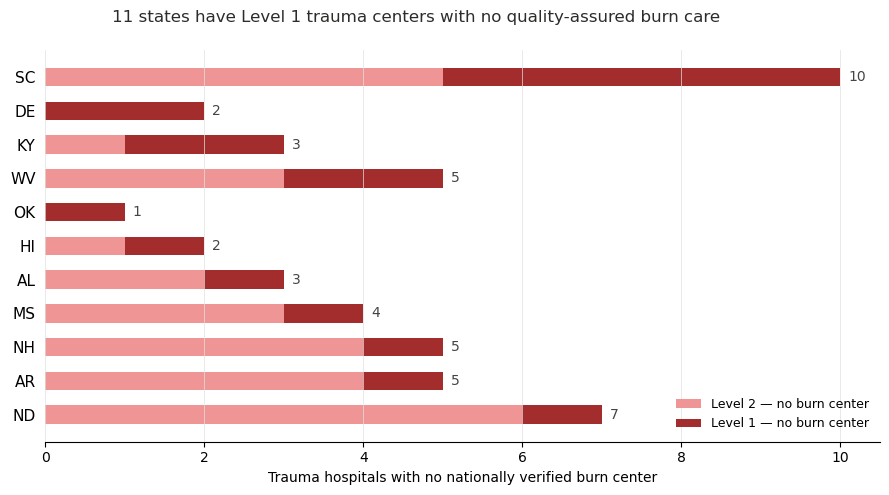

Saved: chart1_critical_states.png


In [12]:
critical_chart = pressure[
    (pressure['nationally_verif'] == 0) &
    (pressure['l1_no_burn'] > 0)
].sort_values('l1_no_burn', ascending=True)

states    = critical_chart['STATE'].tolist()
l1_counts = critical_chart['l1_no_burn'].tolist()
l2_counts = critical_chart['l2_no_burn'].tolist()

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

y = np.arange(len(states))
ax.barh(y, l2_counts, height=0.55, color='#F09595', label='Level 2 — no burn center')
ax.barh(y, l1_counts, height=0.55, color='#A32D2D', left=l2_counts, label='Level 1 — no burn center')

for i, (l1, l2) in enumerate(zip(l1_counts, l2_counts)):
    ax.text(l1 + l2 + 0.1, i, str(l1 + l2), va='center', fontsize=10, color='#444441')

ax.set_yticks(y)
ax.set_yticklabels(states, fontsize=11)
ax.set_xlabel('Trauma hospitals with no nationally verified burn center', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis='x', color='#e0e0e0', linewidth=0.5, zorder=0)

fig.text(0.13, 0.98,
         '11 states have Level 1 trauma centers with no quality-assured burn care',
         fontsize=12, fontweight='500', color='#2C2C2A', va='top')

ax.legend(fontsize=9, frameon=False, loc='lower right')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('chart1_critical_states.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: chart1_critical_states.png')

In [14]:
import pgeocode

nomi = pgeocode.Nominatim('us')

print('Geocoding all hospitals by ZIP code...')

zip_codes  = data_df['ZIP_CODE'].unique()
zip_lookup = {}

for z in zip_codes:
    result = nomi.query_postal_code(z)
    zip_lookup[z] = (result['latitude'], result['longitude'])

data_df['lat'] = data_df['ZIP_CODE'].map(lambda z: zip_lookup[z][0])
data_df['lon'] = data_df['ZIP_CODE'].map(lambda z: zip_lookup[z][1])

print(f'Total hospitals:       {len(data_df)}')
print(f'Successfully geocoded: {data_df["lat"].notna().sum()}')
print(f'Failed to geocode:     {data_df["lat"].isna().sum()}')

Geocoding all hospitals by ZIP code...
Total hospitals:       635
Successfully geocoded: 635
Failed to geocode:     0


In [15]:
data_df

,STATE_FULL,STATE,COUNTY,ADDRESS,CITY,ZIP_CODE,AHA_ID,HOSPITAL_NAME,TOTAL_BEDS,BURN_BEDS,...,is_burn_adult_only,is_l1_trauma,is_l2_trauma,is_aba_verified,is_acs_verified,is_bc_state_desig,verification_tier,is_nationally_verified,lat,lon
0,Alaska,AK,Anchorage,4315 Diplomacy Dr,Anchorage,99508,6940010.0,Alaska Native Medical Center,173,NaN,...,False,False,True,False,True,False,Not a burn center,False,61.2060,-149.8101
1,Alaska,AK,Anchorage,3200 Providence Dr,Anchorage,99508,6940020.0,Providence Alaska Medical Center/Children's Ho...,401,NaN,...,False,False,True,False,True,False,Not a burn center,False,61.2060,-149.8101
2,Alabama,AL,Houston,1108 Ross Clark Cir,Dothan,36301,6530373.0,Southeast Alabama Medical Center,387,NaN,...,False,False,True,False,False,False,Not a burn center,False,31.1481,-85.3718
3,Alabama,AL,Jefferson,619 19th St S,Birmingham,35233,6530304.0,University of Alabama at Birmingham Hospital (...,1157,28.0,...,True,True,False,False,True,False,Tier 4 — No designation,False,33.5062,-86.8003
4,Alabama,AL,Jefferson,1600 7th Ave South,Birmingham,35233,6530170.0,Children's of Alabama (Children's of Alabama B...,351,6.0,...,False,True,False,False,False,False,Tier 4 — No designation,False,33.5062,-86.8003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630,Wisconsin,WI,Milwaukee,2301 North Lake Dr,Milwaukee,53211,6451130.0,Ascension Columbia St. Mary's Hospital Regiona...,273,12.0,...,False,False,False,False,False,False,Tier 4 — No designation,False,43.0820,-87.8895
631,Wisconsin,WI,Rock,1000 Mineral Point Ave,Janesville,53547,6450015.0,Mercyhealth Hospital and Trauma Center,240,NaN,...,False,False,True,False,True,False,Not a burn center,False,42.7294,-89.0301
632,Wisconsin,WI,Waukesha,36500 Aurora Dr,Summit,53066,6450175.0,Aurora Medical Center Summit,117,NaN,...,False,False,True,False,True,False,Not a burn center,False,43.1095,-88.4862
633,Wisconsin,WI,Winnebago,130 2nd St,Neenah,54956,6451290.0,ThedaCare Regional Medical Center - Neenah,150,NaN,...,False,False,True,False,True,False,Not a burn center,False,44.1811,-88.4792


In [16]:
#Distance from every trauma-only hospital to nearest burn center 

def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Separate the two groups
trauma_only = data_df[data_df['is_trauma_only']].dropna(subset=['lat','lon']).copy()
burn_centers_geo = data_df[data_df['is_burn']].dropna(subset=['lat','lon']).copy()

burn_lat = burn_centers_geo['lat'].values
burn_lon = burn_centers_geo['lon'].values

# For each trauma hospital — find nearest ANY burn center
# and nearest NATIONALLY VERIFIED burn center separately
verified_centers = burn_centers_geo[burn_centers_geo['is_nationally_verified']]
ver_lat = verified_centers['lat'].values
ver_lon = verified_centers['lon'].values

distances_any      = []
distances_verified = []
nearest_any_name   = []
nearest_ver_name   = []

for _, row in trauma_only.iterrows():
    # Distance to all burn centers
    d_all = haversine_miles(row['lat'], row['lon'], burn_lat, burn_lon)
    idx_all = np.argmin(d_all)
    distances_any.append(round(d_all[idx_all], 1))
    nearest_any_name.append(burn_centers_geo.iloc[idx_all]['HOSPITAL_NAME'])

    # Distance to verified only
    d_ver = haversine_miles(row['lat'], row['lon'], ver_lat, ver_lon)
    idx_ver = np.argmin(d_ver)
    distances_verified.append(round(d_ver[idx_ver], 1))
    nearest_ver_name.append(verified_centers.iloc[idx_ver]['HOSPITAL_NAME'])

trauma_only['miles_to_nearest_burn']     = distances_any
trauma_only['nearest_burn_center']       = nearest_any_name
trauma_only['miles_to_nearest_verified'] = distances_verified
trauma_only['nearest_verified_center']   = nearest_ver_name

# The quality gap — extra miles needed to reach a verified center
trauma_only['quality_gap_miles'] = (
    trauma_only['miles_to_nearest_verified'] - trauma_only['miles_to_nearest_burn']
).round(1)

print(f'Trauma-only hospitals analysed: {len(trauma_only)}')
print()
print('=== Distance to nearest ANY burn center ===')
print(f'  Average:          {trauma_only["miles_to_nearest_burn"].mean():.1f} miles')
print(f'  Median:           {trauma_only["miles_to_nearest_burn"].median():.1f} miles')
print(f'  > 50 miles away:  {(trauma_only["miles_to_nearest_burn"] > 50).sum()}')
print(f'  > 100 miles away: {(trauma_only["miles_to_nearest_burn"] > 100).sum()}')
print(f'  > 200 miles away: {(trauma_only["miles_to_nearest_burn"] > 200).sum()}')
print()
print('=== Distance to nearest VERIFIED burn center ===')
print(f'  Average:          {trauma_only["miles_to_nearest_verified"].mean():.1f} miles')
print(f'  Median:           {trauma_only["miles_to_nearest_verified"].median():.1f} miles')
print(f'  > 50 miles away:  {(trauma_only["miles_to_nearest_verified"] > 50).sum()}')
print(f'  > 100 miles away: {(trauma_only["miles_to_nearest_verified"] > 100).sum()}')
print(f'  > 200 miles away: {(trauma_only["miles_to_nearest_verified"] > 200).sum()}')
print()
print('=== Quality gap (extra miles to reach verified vs any burn center) ===')
print(f'  Hospitals where nearest burn center is NOT verified: {(trauma_only["quality_gap_miles"] > 0).sum()}')
print(f'  Average extra miles to reach verified center:        {trauma_only[trauma_only["quality_gap_miles"]>0]["quality_gap_miles"].mean():.1f}')

Trauma-only hospitals analysed: 499

=== Distance to nearest ANY burn center ===
  Average:          49.3 miles
  Median:           19.8 miles
  > 50 miles away:  148
  > 100 miles away: 59
  > 200 miles away: 23

=== Distance to nearest VERIFIED burn center ===
  Average:          72.8 miles
  Median:           28.7 miles
  > 50 miles away:  194
  > 100 miles away: 107
  > 200 miles away: 31

=== Quality gap (extra miles to reach verified vs any burn center) ===
  Hospitals where nearest burn center is NOT verified: 163
  Average extra miles to reach verified center:        72.2


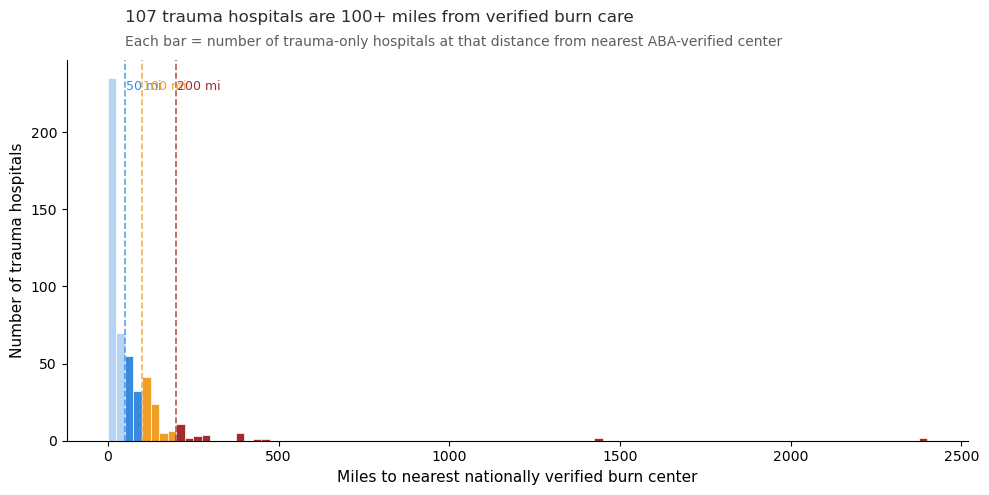

Saved: chart2a_distance_distribution.png


In [17]:
# ── Chart A: Distribution of distances to nearest verified burn center ────────

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

distances = trauma_only['miles_to_nearest_verified']

# Histogram with color zones
bins = range(0, int(distances.max()) + 25, 25)
n, bin_edges, patches = ax.hist(distances, bins=bins, color='#B5D4F4', edgecolor='white', linewidth=0.5)

# Color the danger zones
for patch, left_edge in zip(patches, bin_edges):
    if left_edge >= 200:
        patch.set_facecolor('#A32D2D')
    elif left_edge >= 100:
        patch.set_facecolor('#EF9F27')
    elif left_edge >= 50:
        patch.set_facecolor('#378ADD')

# Reference lines
ax.axvline(50,  color='#378ADD', linewidth=1.2, linestyle='--', alpha=0.8)
ax.axvline(100, color='#EF9F27', linewidth=1.2, linestyle='--', alpha=0.8)
ax.axvline(200, color='#A32D2D', linewidth=1.2, linestyle='--', alpha=0.8)

ax.text(52,  ax.get_ylim()[1]*0.92, '50 mi',  fontsize=9, color='#378ADD')
ax.text(102, ax.get_ylim()[1]*0.92, '100 mi', fontsize=9, color='#EF9F27')
ax.text(202, ax.get_ylim()[1]*0.92, '200 mi', fontsize=9, color='#A32D2D')

ax.set_xlabel('Miles to nearest nationally verified burn center', fontsize=11)
ax.set_ylabel('Number of trauma hospitals', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(0.13, 0.98,
         '107 trauma hospitals are 100+ miles from verified burn care',
         fontsize=12, fontweight='500', color='#2C2C2A', va='top')
fig.text(0.13, 0.93,
         'Each bar = number of trauma-only hospitals at that distance from nearest ABA-verified center',
         fontsize=10, color='#5F5E5A', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig('chart2a_distance_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: chart2a_distance_distribution.png')

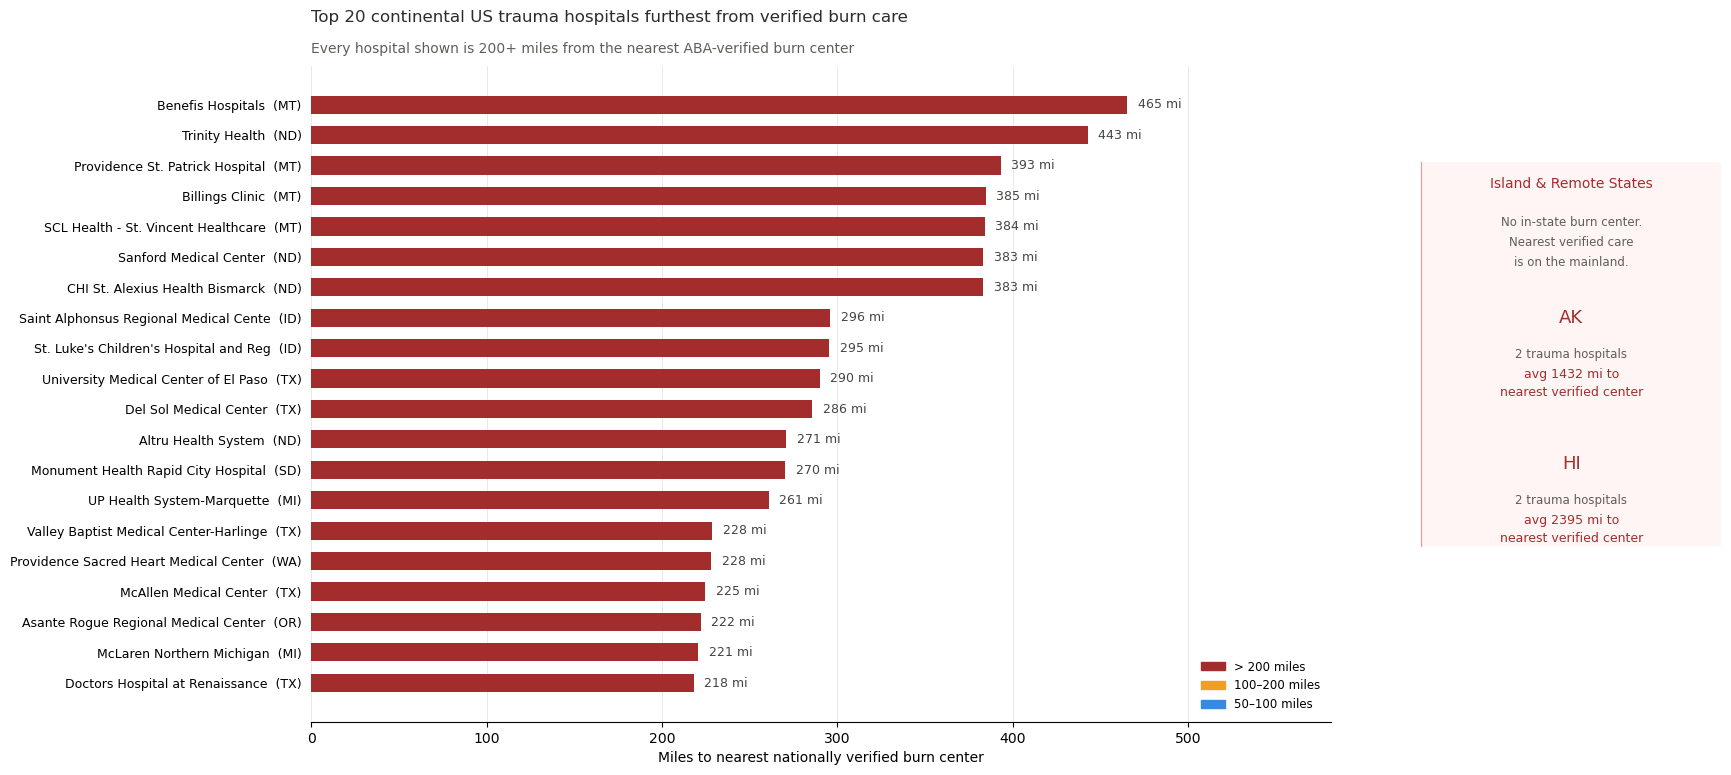

Saved: chart2b_top20_underserved.png


In [20]:

continental = trauma_only[~trauma_only['STATE'].isin(['AK', 'HI'])].copy()
remote      = trauma_only[trauma_only['STATE'].isin(['AK', 'HI'])].copy()

top20 = (
    continental
    .sort_values('miles_to_nearest_verified', ascending=False)
    .head(20)
    .sort_values('miles_to_nearest_verified', ascending=True)
)

labels = (top20['HOSPITAL_NAME'].str[:38] + '  (' + top20['STATE'] + ')').tolist()
values = top20['miles_to_nearest_verified'].tolist()
colors = ['#A32D2D' if v >= 200 else '#EF9F27' if v >= 100 else '#378ADD' for v in values]

fig = plt.figure(figsize=(15, 8))
fig.patch.set_facecolor('white')

# Main chart: left 75%, callout right 20%, gap in between
ax_main = fig.add_axes([0.02, 0.08, 0.68, 0.82])
ax_call = fig.add_axes([0.76, 0.30, 0.20, 0.48])

# ── Main chart ────────────────────────────────────────────────────────────────
ax_main.set_facecolor('white')
y = np.arange(len(labels))
ax_main.barh(y, values, height=0.6, color=colors, zorder=3)

# Push labels further right so they don't overlap bars
for i, v in enumerate(values):
    ax_main.text(v + 6, i, f'{v:.0f} mi', va='center', fontsize=9, color='#444441')

ax_main.set_yticks(y)
ax_main.set_yticklabels(labels, fontsize=9)
ax_main.set_xlabel('Miles to nearest nationally verified burn center', fontsize=10)
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_main.spines['left'].set_visible(False)
ax_main.tick_params(left=False)
ax_main.grid(axis='x', color='#e0e0e0', linewidth=0.5, zorder=0)

# Extra x-axis room so labels don't get cut
ax_main.set_xlim(0, max(values) * 1.25)

legend_elements = [
    mpatches.Patch(color='#A32D2D', label='> 200 miles'),
    mpatches.Patch(color='#EF9F27', label='100–200 miles'),
    mpatches.Patch(color='#378ADD', label='50–100 miles'),
]
ax_main.legend(handles=legend_elements, fontsize=8.5, frameon=False, loc='lower right')

# ── Callout panel ─────────────────────────────────────────────────────────────
ax_call.set_facecolor('#FFF5F5')
for spine in ax_call.spines.values():
    spine.set_visible(False)
ax_call.spines['left'].set_visible(True)
ax_call.spines['left'].set_color('#F09595')
ax_call.tick_params(left=False, bottom=False)
ax_call.set_xticks([])
ax_call.set_yticks([])

ax_call.text(0.5, 0.96, 'Island & Remote States',
             transform=ax_call.transAxes, fontsize=10, fontweight='500',
             color='#A32D2D', ha='center', va='top')
ax_call.text(0.5, 0.86, 'No in-state burn center.\nNearest verified care\nis on the mainland.',
             transform=ax_call.transAxes, fontsize=8.5, color='#5F5E5A',
             ha='center', va='top', linespacing=1.7)

y_pos = 0.58
for state in ['AK', 'HI']:
    state_rows  = remote[remote['STATE'] == state]
    n_hospitals = len(state_rows)
    avg_dist    = state_rows['miles_to_nearest_verified'].mean()
    ax_call.text(0.5, y_pos,        state,
                 transform=ax_call.transAxes, fontsize=13, fontweight='500',
                 color='#A32D2D', ha='center')
    ax_call.text(0.5, y_pos - 0.09, f'{n_hospitals} trauma hospitals',
                 transform=ax_call.transAxes, fontsize=8.5, color='#5F5E5A', ha='center')
    ax_call.text(0.5, y_pos - 0.19, f'avg {avg_dist:.0f} mi to\nnearest verified center',
                 transform=ax_call.transAxes, fontsize=9, color='#A32D2D',
                 ha='center', fontweight='500', linespacing=1.5)
    y_pos -= 0.38

# ── Titles ────────────────────────────────────────────────────────────────────
fig.text(0.02, 0.97,
         'Top 20 continental US trauma hospitals furthest from verified burn care',
         fontsize=12, fontweight='500', color='#2C2C2A', va='top')
fig.text(0.02, 0.93,
         'Every hospital shown is 200+ miles from the nearest ABA-verified burn center',
         fontsize=10, color='#5F5E5A', va='top')

plt.savefig('chart2b_top20_underserved.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: chart2b_top20_underserved.png')

In [21]:
# ── Burn bed availability relative to trauma volume proxy ─────────────────────

# Supply: burn beds by state (only from centers with known counts)
burn_beds_by_state = (
    burn_with_beds
    .groupby('STATE')['BURN_BEDS']
    .sum()
    .reset_index()
    .rename(columns={'BURN_BEDS': 'total_burn_beds'})
)

# Demand proxy: trauma-only hospitals by state
trauma_by_state = (
    data_df[data_df['is_trauma_only']]
    .groupby('STATE')
    .agg(
        trauma_only_hospitals = ('HOSPITAL_NAME', 'count'),
        l1_hospitals          = ('is_l1_trauma',  'sum'),
    )
    .reset_index()
)

# Merge supply and demand
supply_demand = (
    state_burn_summary[['STATE', 'burn_centers', 'nationally_verif']]
    .merge(burn_beds_by_state, on='STATE', how='left')
    .merge(trauma_by_state,    on='STATE', how='left')
)

supply_demand['total_burn_beds']        = supply_demand['total_burn_beds'].fillna(0).astype(int)
supply_demand['trauma_only_hospitals']  = supply_demand['trauma_only_hospitals'].fillna(0).astype(int)
supply_demand['l1_hospitals']           = supply_demand['l1_hospitals'].fillna(0).astype(int)

# The core metric: burn beds per trauma-only hospital
# Low number = each burn bed is serving many trauma hospitals = under-resourced
supply_demand['beds_per_trauma_hospital'] = (
    supply_demand['total_burn_beds'] / (supply_demand['trauma_only_hospitals'] + 1)
).round(1)

# States with zero burn beds but trauma hospitals = worst case
supply_demand = supply_demand.sort_values('beds_per_trauma_hospital', ascending=True)

print('MOST UNDER-RESOURCED STATES (fewest burn beds per trauma hospital):')
print()
print(f"{'STATE':<6} {'Burn Beds':>9} {'Trauma Hosp':>11} {'L1':>4} {'Beds/Trauma Hosp':>17}")
print('-' * 52)
for _, row in supply_demand.head(15).iterrows():
    print(f"  {row['STATE']:<6} {int(row['total_burn_beds']):>9} {int(row['trauma_only_hospitals']):>11} {int(row['l1_hospitals']):>4} {row['beds_per_trauma_hospital']:>17.1f}")

print()
print('BEST RESOURCED STATES:')
print()
for _, row in supply_demand.tail(5).iterrows():
    print(f"  {row['STATE']:<6} {int(row['total_burn_beds']):>9} {int(row['trauma_only_hospitals']):>11} {int(row['l1_hospitals']):>4} {row['beds_per_trauma_hospital']:>17.1f}")

MOST UNDER-RESOURCED STATES (fewest burn beds per trauma hospital):

STATE  Burn Beds Trauma Hosp   L1  Beds/Trauma Hosp
----------------------------------------------------
  AK             0           2    0               0.0
  SD             0           3    0               0.0
  RI             0           0    0               0.0
  NH             0           4    1               0.0
  ND             0           6    1               0.0
  MT             0           4    0               0.0
  MS             0           4    1               0.0
  DE             0           2    2               0.0
  WV             4           4    2               0.8
  CT             9          11    4               0.8
  NJ            12          10    6               1.1
  IL            77          52   14               1.5
  AR            10           5    1               1.7
  UT            15           7    2               1.9
  MI            69          30    5               2.2

BEST RESOURCED 

In [22]:
# Quick check on states showing 0 burn beds
zero_bed_states = supply_demand[supply_demand['total_burn_beds'] == 0]
print('States with 0 burn beds and why:')
print()
for _, row in zero_bed_states.iterrows():
    state = row['STATE']
    centers = data_df[data_df['STATE'] == state]['is_burn'].sum()
    beds_known = burn_with_beds[burn_with_beds['STATE'] == state]['BURN_BEDS'].sum() if state in burn_with_beds['STATE'].values else 0
    print(f"  {state}: burn_centers={int(centers)}, known_beds={int(beds_known)}, trauma_hospitals={int(row['trauma_only_hospitals'])}")

States with 0 burn beds and why:

  AK: burn_centers=0, known_beds=0, trauma_hospitals=2
  SD: burn_centers=0, known_beds=0, trauma_hospitals=3
  RI: burn_centers=1, known_beds=0, trauma_hospitals=0
  NH: burn_centers=0, known_beds=0, trauma_hospitals=4
  ND: burn_centers=0, known_beds=0, trauma_hospitals=6
  MT: burn_centers=0, known_beds=0, trauma_hospitals=4
  MS: burn_centers=0, known_beds=0, trauma_hospitals=4
  DE: burn_centers=0, known_beds=0, trauma_hospitals=2


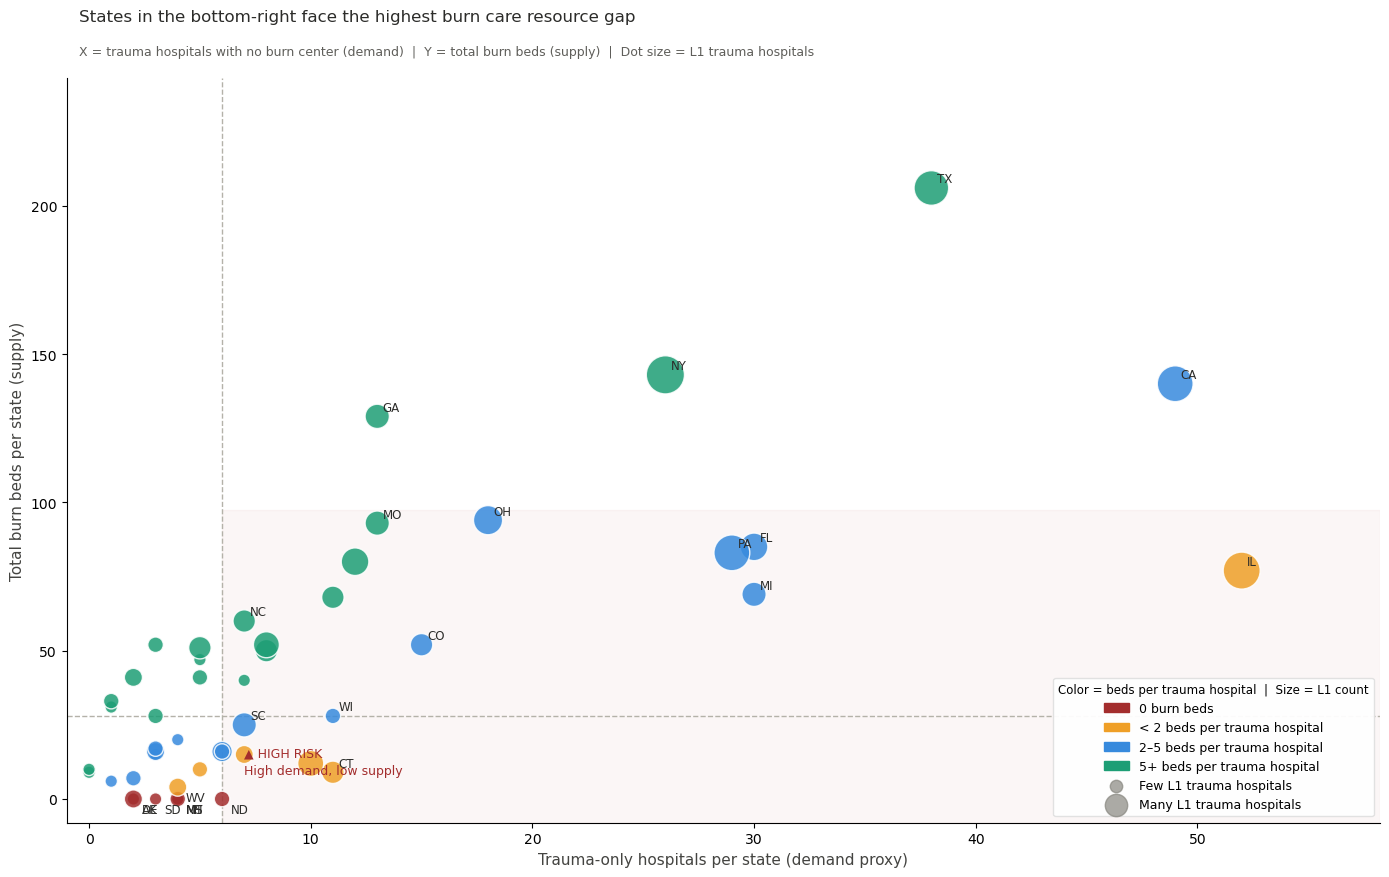

Saved: chart3_supply_demand_scatter.png


In [27]:
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

scatter_df = supply_demand[supply_demand['STATE'] != 'RI'].copy()

median_trauma = scatter_df['trauma_only_hospitals'].median()
median_beds   = scatter_df['total_burn_beds'].median()

# Quadrant shading
ax.axvspan(median_trauma, scatter_df['trauma_only_hospitals'].max() * 1.12,
           ymin=0, ymax=0.42, alpha=0.04, color='#A32D2D', zorder=0)
ax.axvline(median_trauma, color='#B4B2A9', linewidth=1, linestyle='--', zorder=1)
ax.axhline(median_beds,   color='#B4B2A9', linewidth=1, linestyle='--', zorder=1)

def get_color(ratio):
    if ratio == 0:   return '#A32D2D'
    elif ratio < 2:  return '#EF9F27'
    elif ratio < 5:  return '#378ADD'
    else:            return '#1D9E75'

colors = [get_color(r) for r in scatter_df['beds_per_trauma_hospital']]
sizes  = (scatter_df['l1_hospitals'] * 45 + 80).tolist()

ax.scatter(
    scatter_df['trauma_only_hospitals'],
    scatter_df['total_burn_beds'],
    c=colors, s=sizes, alpha=0.85, zorder=3,
    edgecolors='white', linewidths=1
)

# ── Smart labeling ─────────────────────────────────────────────────────────────
# Label only the analytically important states — avoids clutter
highlight_states = [
    'IL', 'TX', 'CA', 'NY', 'FL', 'MI', 'PA',
    'OH', 'GA', 'MO', 'CO', 'NC', 'WI', 'CT',
    'ND', 'MT', 'MS', 'DE', 'AK', 'SD', 'NH', 'WV', 'SC'
]

for _, row in scatter_df.iterrows():
    if row['STATE'] in highlight_states:
        # States in the crowded bottom left get offset labels
        x_off, y_off = 4, 4
        if row['trauma_only_hospitals'] < 8 and row['total_burn_beds'] < 20:
            x_off, y_off = 6, -10
        ax.annotate(
            row['STATE'],
            xy=(row['trauma_only_hospitals'], row['total_burn_beds']),
            xytext=(x_off, y_off), textcoords='offset points',
            fontsize=8.5, color='#2C2C2A', fontweight='500'
        )

# ── HIGH RISK label ────────────────────────────────────────────────────────────
ax.text(median_trauma + 1, median_beds * 0.3,
        '▲ HIGH RISK\nHigh demand, low supply',
        fontsize=9, color='#A32D2D', fontweight='500', linespacing=1.5)

# ── Axes ───────────────────────────────────────────────────────────────────────
ax.set_xlabel('Trauma-only hospitals per state (demand proxy)', fontsize=11, color='#444441')
ax.set_ylabel('Total burn beds per state (supply)', fontsize=11, color='#444441')
ax.set_xlim(-1, scatter_df['trauma_only_hospitals'].max() * 1.12)
ax.set_ylim(-8, scatter_df['total_burn_beds'].max() * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Legend — placed bottom right, away from dots ──────────────────────────────
legend_elements = [
    mpatches.Patch(color='#A32D2D', label='0 burn beds'),
    mpatches.Patch(color='#EF9F27', label='< 2 beds per trauma hospital'),
    mpatches.Patch(color='#378ADD', label='2–5 beds per trauma hospital'),
    mpatches.Patch(color='#1D9E75', label='5+ beds per trauma hospital'),
    plt.scatter([], [], s=80,  color='#888780', alpha=0.7, label='Few L1 trauma hospitals'),
    plt.scatter([], [], s=260, color='#888780', alpha=0.7, label='Many L1 trauma hospitals'),
]
ax.legend(handles=legend_elements, fontsize=9, frameon=True,
          framealpha=0.95, edgecolor='#e0e0e0',
          loc='lower right',
          title='Color = beds per trauma hospital  |  Size = L1 count',
          title_fontsize=8.5)

# ── Titles ─────────────────────────────────────────────────────────────────────
fig.text(0.06, 0.97,
         'States in the bottom-right face the highest burn care resource gap',
         fontsize=12, fontweight='500', color='#2C2C2A', va='top')
fig.text(0.06, 0.93,
         'X = trauma hospitals with no burn center (demand)  |  Y = total burn beds (supply)  |  Dot size = L1 trauma hospitals',
         fontsize=9, color='#5F5E5A', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig('chart3_supply_demand_scatter.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: chart3_supply_demand_scatter.png')

In [28]:
#Pediatric burn coverage flags

data_df['is_peds_trauma']      = (data_df['PEDS_TRAUMA_L1'] == 1) | (data_df['PEDS_TRAUMA_L2'] == 1)
data_df['is_peds_trauma_only'] = data_df['is_peds_trauma'] & ~data_df['is_burn_peds']

peds_state = (
    data_df
    .groupby('STATE')
    .agg(
        burn_centers_any    = ('is_burn',             'sum'),
        peds_burn_centers   = ('is_burn_peds',        'sum'),
        adult_only_centers  = ('is_burn_adult_only',  'sum'),
        peds_trauma_hosp    = ('is_peds_trauma',      'sum'),
        peds_trauma_no_burn = ('is_peds_trauma_only', 'sum'),
        l1_peds_trauma      = ('PEDS_TRAUMA_L1',      'sum'),
    )
    .reset_index()
)

no_peds_burn = peds_state[peds_state['peds_burn_centers'] == 0].sort_values(
    'peds_trauma_no_burn', ascending=False
)

print(f'Total burn centers (any):          {data_df["is_burn"].sum()}')
print(f'  — with pediatric capability:     {data_df["is_burn_peds"].sum()}')
print(f'  — adult-only:                    {data_df["is_burn_adult_only"].sum()}')
print(f'Pediatric trauma hospitals:        {data_df["is_peds_trauma"].sum()}')
print(f'  — without peds burn center:      {data_df["is_peds_trauma_only"].sum()}')
print()
print(f'States with NO pediatric burn center: {len(no_peds_burn)}')
print()
print(f"{'STATE':<6} {'Any Burn':>8} {'Peds Burn':>9} {'Peds Trauma':>11} {'Peds Trauma, No Peds Burn':>26}")
print('-' * 65)
for _, row in no_peds_burn.iterrows():
    print(f"  {row['STATE']:<6} {int(row['burn_centers_any']):>8} {int(row['peds_burn_centers']):>9} "
          f"{int(row['peds_trauma_hosp']):>11} {int(row['peds_trauma_no_burn']):>26}")

Total burn centers (any):          136
  — with pediatric capability:     89
  — adult-only:                    47
Pediatric trauma hospitals:        146
  — without peds burn center:      100

States with NO pediatric burn center: 12

STATE  Any Burn Peds Burn Peds Trauma  Peds Trauma, No Peds Burn
-----------------------------------------------------------------
  AK            0         0           2                          2
  CT            1         0           2                          2
  KY            1         0           2                          2
  DE            0         0           1                          1
  ND            0         0           1                          1
  NH            0         0           1                          1
  SD            0         0           1                          1
  VT            1         0           1                          1
  WV            1         0           1                          1
  ME            1         0   

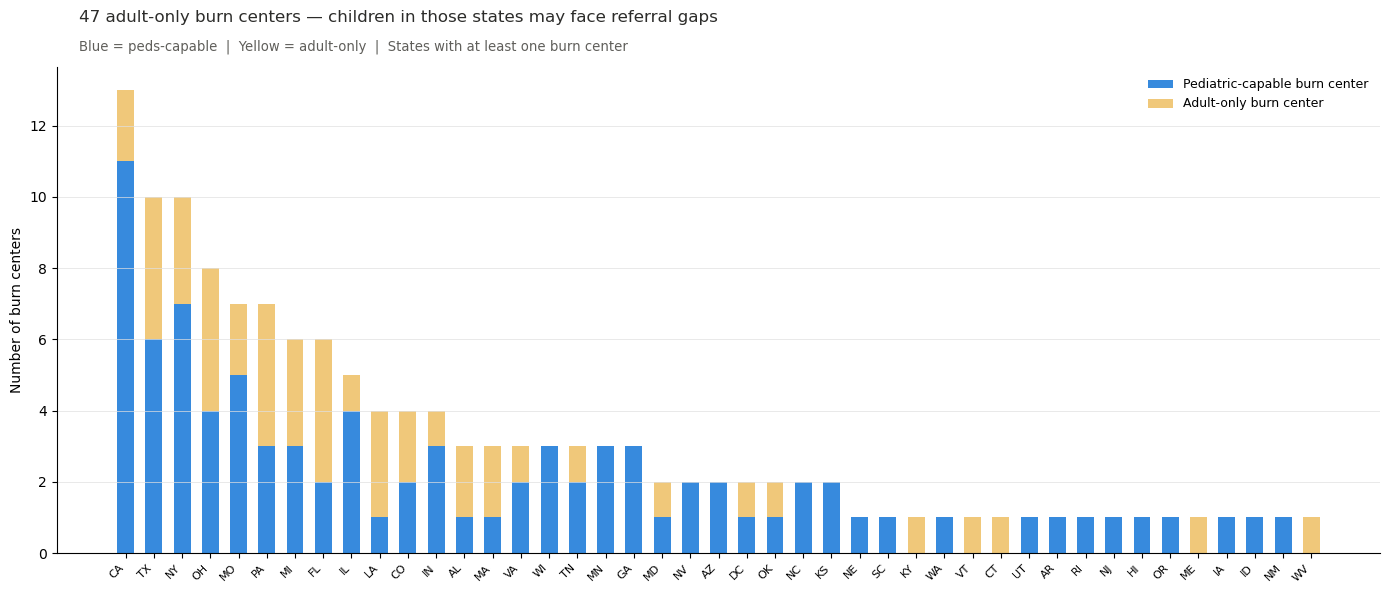

In [29]:
# Burn center type by state (peds vs adult-only)
import matplotlib.ticker as mticker

chart_df = (
    data_df[data_df['is_burn']]
    .groupby('STATE')
    .agg(
        peds_burn  = ('is_burn_peds',       'sum'),
        adult_only = ('is_burn_adult_only', 'sum'),
    )
    .reset_index()
)
chart_df['total'] = chart_df['peds_burn'] + chart_df['adult_only']
chart_df = chart_df[chart_df['total'] > 0].sort_values('total', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x = np.arange(len(chart_df))
ax.bar(x, chart_df['peds_burn'],  color='#378ADD', label='Pediatric-capable burn center', width=0.6)
ax.bar(x, chart_df['adult_only'], color='#F0C87A', label='Adult-only burn center',        width=0.6,
       bottom=chart_df['peds_burn'])

ax.set_xticks(x)
ax.set_xticklabels(chart_df['STATE'], fontsize=8, rotation=45, ha='right')
ax.set_ylabel('Number of burn centers', fontsize=10)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.5, zorder=0)
ax.legend(fontsize=9, frameon=False)

fig.text(0.06, 0.98,
         '47 adult-only burn centers — children in those states may face referral gaps',
         fontsize=12, fontweight='500', color='#2C2C2A', va='top')
fig.text(0.06, 0.93,
         'Blue = peds-capable  |  Yellow = adult-only  |  States with at least one burn center',
         fontsize=9.5, color='#5F5E5A', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

In [30]:
#Distance: peds trauma-only hospitals → nearest PEDIATRIC burn center

peds_trauma_only_geo = (
    data_df[data_df['is_peds_trauma_only']]
    .dropna(subset=['lat', 'lon'])
    .copy()
)
peds_burn_geo = (
    data_df[data_df['is_burn_peds']]
    .dropna(subset=['lat', 'lon'])
    .copy()
)

pb_lat = peds_burn_geo['lat'].values
pb_lon = peds_burn_geo['lon'].values

dist_to_peds_burn = []
nearest_pb_name   = []

for _, row in peds_trauma_only_geo.iterrows():
    d   = haversine_miles(row['lat'], row['lon'], pb_lat, pb_lon)
    idx = np.argmin(d)
    dist_to_peds_burn.append(round(d[idx], 1))
    nearest_pb_name.append(peds_burn_geo.iloc[idx]['HOSPITAL_NAME'])

peds_trauma_only_geo['miles_to_nearest_peds_burn'] = dist_to_peds_burn
peds_trauma_only_geo['nearest_peds_burn_center']   = nearest_pb_name

print(f'Peds trauma hospitals with no in-state peds burn center: {len(peds_trauma_only_geo)}')
print()
print('=== Distance to nearest PEDIATRIC burn center ===')
print(f'  Average:     {peds_trauma_only_geo["miles_to_nearest_peds_burn"].mean():.1f} miles')
print(f'  Median:      {peds_trauma_only_geo["miles_to_nearest_peds_burn"].median():.1f} miles')
print(f'  > 50 miles:  {(peds_trauma_only_geo["miles_to_nearest_peds_burn"] > 50).sum()}')
print(f'  > 100 miles: {(peds_trauma_only_geo["miles_to_nearest_peds_burn"] > 100).sum()}')
print(f'  > 200 miles: {(peds_trauma_only_geo["miles_to_nearest_peds_burn"] > 200).sum()}')
print()
print('Top 10 most isolated peds trauma hospitals:')
for _, r in peds_trauma_only_geo.sort_values('miles_to_nearest_peds_burn', ascending=False).head(10).iterrows():
    print(f"  {r['miles_to_nearest_peds_burn']:>6.1f} mi  {r['HOSPITAL_NAME'][:55]}  ({r['STATE']})")

Peds trauma hospitals with no in-state peds burn center: 100

=== Distance to nearest PEDIATRIC burn center ===
  Average:     77.9 miles
  Median:      26.8 miles
  > 50 miles:  40
  > 100 miles: 20
  > 200 miles: 6

Top 10 most isolated peds trauma hospitals:
  1431.9 mi  Alaska Native Medical Center  (AK)
  1431.9 mi  Providence Alaska Medical Center/Children's Hospital at  (AK)
   228.0 mi  Providence Sacred Heart Medical Center & Children's Hos  (WA)
   213.2 mi  Sanford Medical Center Fargo  (ND)
   209.8 mi  Ascension Sacred Heart Pensacola  (FL)
   208.2 mi  St. Luke's Children's Hospital and Regional Medical Cen  (ID)
   196.3 mi  Sanford USD Medical Center  (SD)
   176.3 mi  The University of Vermont Medical Center (University of  (VT)
   169.4 mi  Wolfson Children's Hospital  (FL)
   129.2 mi  Le Bonheur Children's Hospital  (TN)


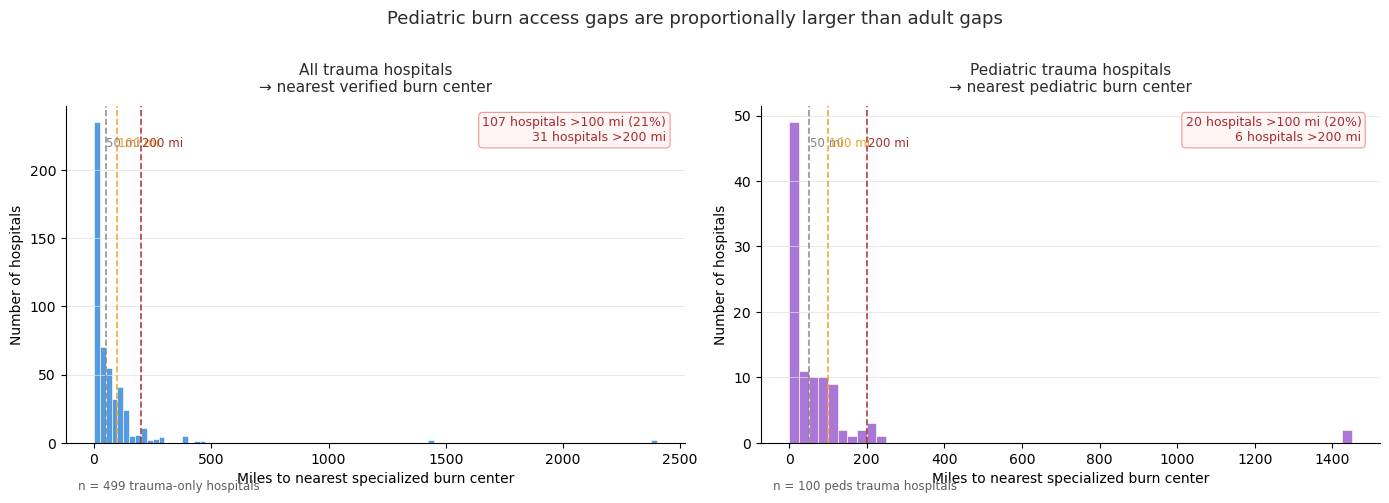

In [31]:
#Adult vs peds distance gap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

panels = [
    {
        'ax':      axes[0],
        'data':    trauma_only['miles_to_nearest_verified'],   # already computed
        'color':   '#378ADD',
        'title':   'All trauma hospitals\n→ nearest verified burn center',
        'n_label': f'n = {len(trauma_only)} trauma-only hospitals',
    },
    {
        'ax':      axes[1],
        'data':    peds_trauma_only_geo['miles_to_nearest_peds_burn'],  # just computed
        'color':   '#9B5FD1',
        'title':   'Pediatric trauma hospitals\n→ nearest pediatric burn center',
        'n_label': f'n = {len(peds_trauma_only_geo)} peds trauma hospitals',
    },
]

for p in panels:
    ax, data = p['ax'], p['data']
    ax.set_facecolor('white')
    bins = range(0, int(data.max()) + 25, 25)
    ax.hist(data, bins=bins, color=p['color'], alpha=0.85, edgecolor='white', linewidth=0.5)

    ylim = ax.get_ylim()[1]
    for threshold, color, label in [(50, '#888780', '50 mi'), (100, '#EF9F27', '100 mi'), (200, '#A32D2D', '200 mi')]:
        ax.axvline(threshold, color=color, linewidth=1.2, linestyle='--', alpha=0.9)
        ax.text(threshold + 3, ylim * 0.88, label, fontsize=8.5, color=color)

    gt100 = (data > 100).sum()
    gt200 = (data > 200).sum()
    ax.text(0.97, 0.97,
            f'{gt100} hospitals >100 mi ({gt100/len(data)*100:.0f}%)\n{gt200} hospitals >200 mi',
            transform=ax.transAxes, fontsize=9, color='#A32D2D', ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF5F5', edgecolor='#F09595', linewidth=0.8))

    ax.set_title(p['title'], fontsize=11, fontweight='500', color='#2C2C2A', pad=10)
    ax.set_xlabel('Miles to nearest specialized burn center', fontsize=10)
    ax.set_ylabel('Number of hospitals', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='#e0e0e0', linewidth=0.5, zorder=0)
    ax.text(0.02, -0.14, p['n_label'], transform=ax.transAxes, fontsize=8.5, color='#5F5E5A')

fig.suptitle('Pediatric burn access gaps are proportionally larger than adult gaps',
             fontsize=13, fontweight='500', color='#2C2C2A', y=1.01)
plt.tight_layout()
plt.show()

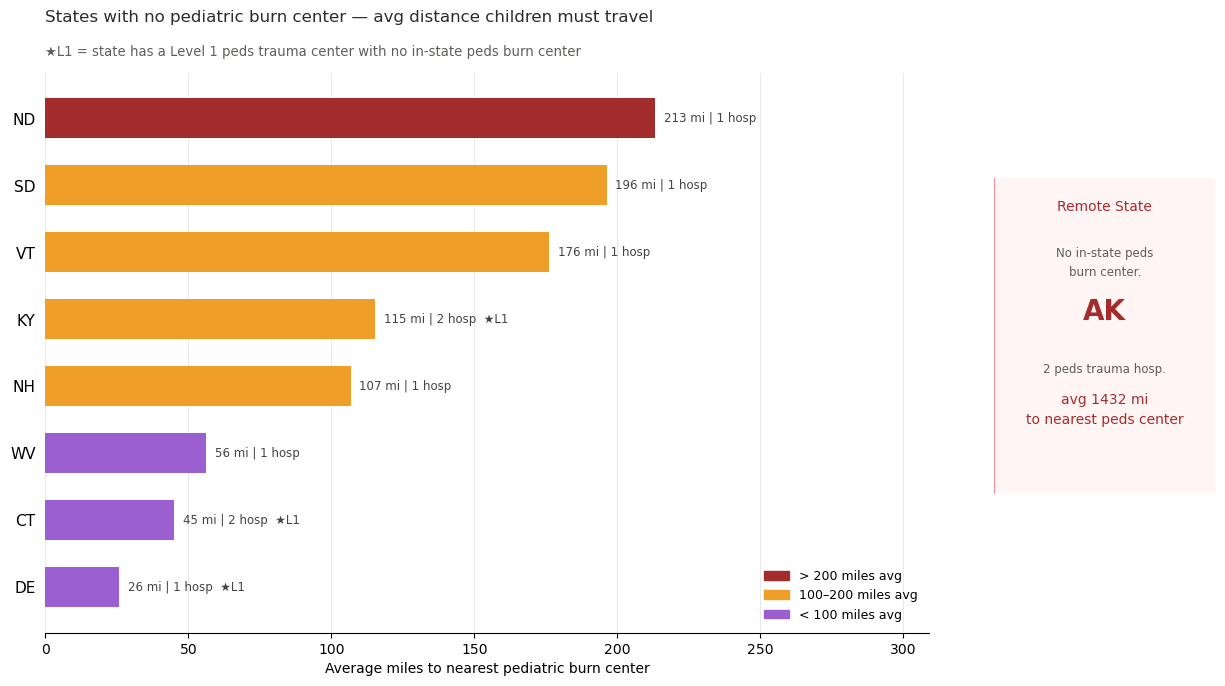

In [34]:
# ── Chart 4c: States with no peds burn center — AK as callout

peds_gap_states = (
    peds_trauma_only_geo
    .groupby('STATE')
    .agg(
        hospital_count        = ('HOSPITAL_NAME',              'count'),
        avg_dist_to_peds_burn = ('miles_to_nearest_peds_burn', 'mean'),
        l1_peds_count         = ('PEDS_TRAUMA_L1',             'sum'),
    )
    .reset_index()
)

states_with_peds_burn = data_df[data_df['is_burn_peds']]['STATE'].unique()
peds_gap_states = peds_gap_states[~peds_gap_states['STATE'].isin(states_with_peds_burn)]
peds_gap_states['avg_dist_to_peds_burn'] = peds_gap_states['avg_dist_to_peds_burn'].round(1)
peds_gap_states = peds_gap_states.sort_values('avg_dist_to_peds_burn', ascending=True)

# Split AK out as callout
mainland = peds_gap_states[peds_gap_states['STATE'] != 'AK'].copy()
ak_row   = peds_gap_states[peds_gap_states['STATE'] == 'AK'].iloc[0]

dists      = mainland['avg_dist_to_peds_burn'].tolist()
bar_colors = ['#A32D2D' if d >= 200 else '#EF9F27' if d >= 100 else '#9B5FD1' for d in dists]

fig = plt.figure(figsize=(13, 7))
fig.patch.set_facecolor('white')

ax_main = fig.add_axes([0.07, 0.08, 0.68, 0.80])
ax_call = fig.add_axes([0.80, 0.28, 0.17, 0.45])

# ── Main chart ────────────────────────────────────────────────────────────────
ax_main.set_facecolor('white')
y = np.arange(len(mainland))
ax_main.barh(y, dists, height=0.6, color=bar_colors, zorder=3)

for i, (_, row) in enumerate(mainland.iterrows()):
    l1_tag = '  ★L1' if row['l1_peds_count'] > 0 else ''
    ax_main.text(row['avg_dist_to_peds_burn'] + 3, i,
                 f"{row['avg_dist_to_peds_burn']:.0f} mi | {int(row['hospital_count'])} hosp{l1_tag}",
                 va='center', fontsize=8.5, color='#444441')

ax_main.set_yticks(y)
ax_main.set_yticklabels(mainland['STATE'], fontsize=11)
ax_main.set_xlabel('Average miles to nearest pediatric burn center', fontsize=10)
ax_main.set_xlim(0, max(dists) * 1.45)
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_main.spines['left'].set_visible(False)
ax_main.tick_params(left=False)
ax_main.grid(axis='x', color='#e0e0e0', linewidth=0.5, zorder=0)

ax_main.legend(handles=[
    mpatches.Patch(color='#A32D2D', label='> 200 miles avg'),
    mpatches.Patch(color='#EF9F27', label='100–200 miles avg'),
    mpatches.Patch(color='#9B5FD1', label='< 100 miles avg'),
], fontsize=9, frameon=False, loc='lower right')

# ── AK callout panel ──────────────────────────────────────────────────────────
ax_call.set_facecolor('#FFF5F5')
for spine in ax_call.spines.values():
    spine.set_visible(False)
ax_call.spines['left'].set_visible(True)
ax_call.spines['left'].set_color('#F09595')
ax_call.tick_params(left=False, bottom=False)
ax_call.set_xticks([])
ax_call.set_yticks([])

ax_call.text(0.5, 0.93, 'Remote State',
             transform=ax_call.transAxes, fontsize=10, fontweight='500',
             color='#A32D2D', ha='center', va='top')
ax_call.text(0.5, 0.78, 'No in-state peds\nburn center.',
             transform=ax_call.transAxes, fontsize=8.5, color='#5F5E5A',
             ha='center', va='top', linespacing=1.6)
ax_call.text(0.5, 0.55, 'AK',
             transform=ax_call.transAxes, fontsize=20, fontweight='700',
             color='#A32D2D', ha='center')
ax_call.text(0.5, 0.38, f"{int(ak_row['hospital_count'])} peds trauma hosp.",
             transform=ax_call.transAxes, fontsize=8.5, color='#5F5E5A', ha='center')
ax_call.text(0.5, 0.22, f"avg {ak_row['avg_dist_to_peds_burn']:.0f} mi\nto nearest peds center",
             transform=ax_call.transAxes, fontsize=10, fontweight='500',
             color='#A32D2D', ha='center', linespacing=1.5)

# ── Titles ────────────────────────────────────────────────────────────────────
fig.text(0.07, 0.97,
         'States with no pediatric burn center — avg distance children must travel',
         fontsize=12, fontweight='500', color='#2C2C2A', va='top')
fig.text(0.07, 0.92,
         '★L1 = state has a Level 1 peds trauma center with no in-state peds burn center',
         fontsize=9.5, color='#5F5E5A', va='top')

plt.show()

In [35]:
# ── Referral pathway classification
# Classifies each trauma-only hospital's referral pathway to burn care

def classify_pathway(row):
    dist_ver = row['miles_to_nearest_verified']
    gap      = row['quality_gap_miles']
    if dist_ver > 200:                return 'Isolated (>200 mi to verified)'
    elif dist_ver > 100:              return 'Long-haul (100–200 mi to verified)'
    elif gap > 0 and dist_ver <= 100: return 'Nearby but unverified only'
    else:                             return 'Direct to verified (<100 mi)'

trauma_only['pathway_class'] = trauma_only.apply(classify_pathway, axis=1)

pathway_order = [
    'Direct to verified (<100 mi)',
    'Nearby but unverified only',
    'Long-haul (100–200 mi to verified)',
    'Isolated (>200 mi to verified)',
]
pathway_colors_list = ['#1D9E75', '#EF9F27', '#E07B39', '#A32D2D']

pway_counts = trauma_only['pathway_class'].value_counts().reindex(pathway_order)

print('=== Referral Pathway Classification (all 499 trauma-only hospitals) ===\n')
for cls, n in pway_counts.items():
    print(f'  {cls:<42}  {n:>4}  ({n/len(trauma_only)*100:.1f}%)')

print()
print('--- Breakdown by trauma level ---')
for label, mask in [('L1', trauma_only['is_l1_trauma']), ('L2', trauma_only['is_l2_trauma'])]:
    sub = trauma_only[mask]
    print(f'\n  {label} trauma ({len(sub)} hospitals):')
    for cls in pathway_order:
        n = (sub['pathway_class'] == cls).sum()
        print(f'    {cls:<42} {n:>4}  ({n/len(sub)*100:.1f}%)')

=== Referral Pathway Classification (all 499 trauma-only hospitals) ===

  Direct to verified (<100 mi)                 299  (59.9%)
  Nearby but unverified only                    93  (18.6%)
  Long-haul (100–200 mi to verified)            76  (15.2%)
  Isolated (>200 mi to verified)                31  (6.2%)

--- Breakdown by trauma level ---

  L1 trauma (170 hospitals):
    Direct to verified (<100 mi)                107  (62.9%)
    Nearby but unverified only                   36  (21.2%)
    Long-haul (100–200 mi to verified)           23  (13.5%)
    Isolated (>200 mi to verified)                4  (2.4%)

  L2 trauma (357 hospitals):
    Direct to verified (<100 mi)                205  (57.4%)
    Nearby but unverified only                   65  (18.2%)
    Long-haul (100–200 mi to verified)           59  (16.5%)
    Isolated (>200 mi to verified)               28  (7.8%)


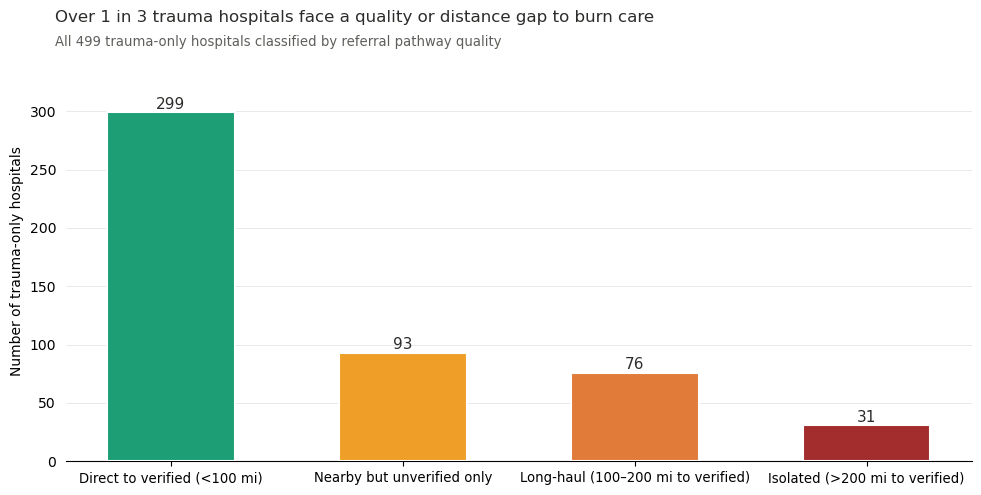

In [36]:
# ── Chart:Referral pathway distribution across all trauma-only hospitals ──

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

counts_list = [pway_counts.get(p, 0) for p in pathway_order]
bars = ax.bar(pathway_order, counts_list, color=pathway_colors_list,
              width=0.55, zorder=3, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, counts_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(count), ha='center', fontsize=11, fontweight='500', color='#2C2C2A')

ax.set_ylabel('Number of trauma-only hospitals', fontsize=10)
ax.set_ylim(0, max(counts_list) * 1.15)
ax.set_xticklabels(pathway_order, fontsize=9.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.5, zorder=0)

fig.text(0.06, 0.98,
         'Over 1 in 3 trauma hospitals face a quality or distance gap to burn care',
         fontsize=12, fontweight='500', color='#2C2C2A', va='top')
fig.text(0.06, 0.93,
         'All 499 trauma-only hospitals classified by referral pathway quality',
         fontsize=9.5, color='#5F5E5A', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

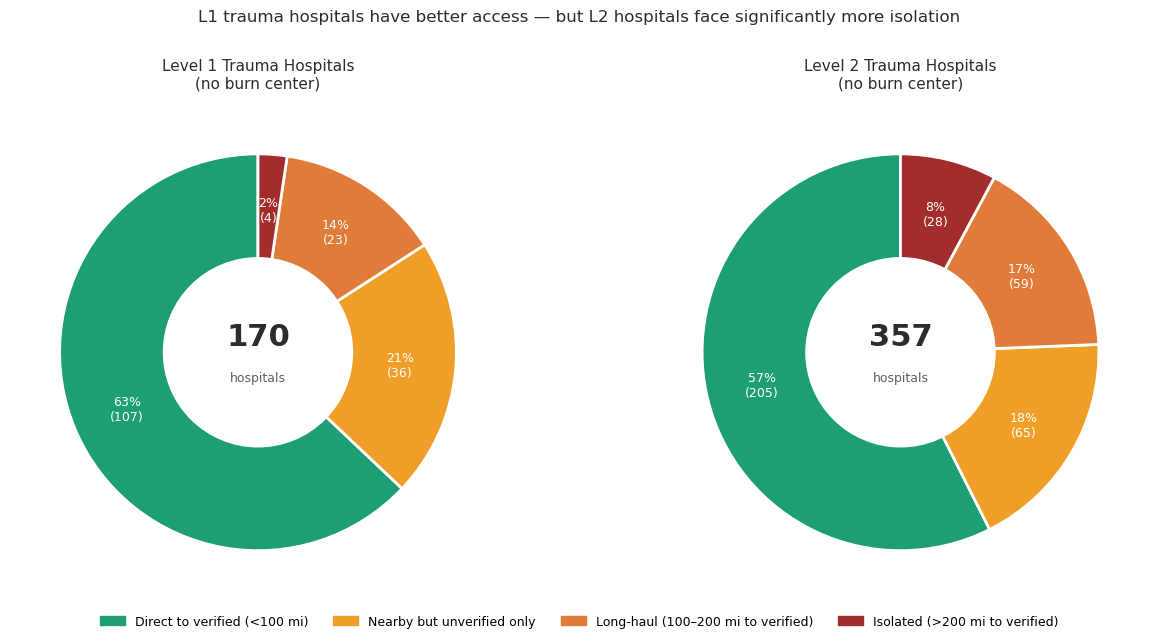

In [37]:
#Pathway breakdown — L1 vs L2 trauma hospitals 

l1_data = trauma_only[trauma_only['is_l1_trauma']]
l2_data = trauma_only[trauma_only['is_l2_trauma']]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('white')

for ax, sub, title in zip(
    axes,
    [l1_data, l2_data],
    ['Level 1 Trauma Hospitals\n(no burn center)', 'Level 2 Trauma Hospitals\n(no burn center)']
):
    ax.set_facecolor('white')
    counts_pie = [sub['pathway_class'].value_counts().get(p, 0) for p in pathway_order]
    total      = sum(counts_pie)

    _, _, autotexts = ax.pie(
        counts_pie,
        colors=pathway_colors_list,
        autopct=lambda pct: f'{pct:.0f}%\n({int(round(pct*total/100))})',
        pctdistance=0.72,
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2),
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_color('white')
        at.set_fontweight('500')

    ax.add_patch(plt.Circle((0, 0), 0.48, fc='white'))
    ax.text(0,  0.08, str(total),  ha='center', va='center',
            fontsize=22, fontweight='700', color='#2C2C2A')
    ax.text(0, -0.13, 'hospitals', ha='center', va='center',
            fontsize=9, color='#5F5E5A')
    ax.set_title(title, fontsize=11, fontweight='500', color='#2C2C2A', pad=12)

fig.legend(
    handles=[mpatches.Patch(color=c, label=l)
             for c, l in zip(pathway_colors_list, pathway_order)],
    loc='lower center', ncol=4, fontsize=9,
    frameon=False, bbox_to_anchor=(0.5, -0.04)
)
fig.suptitle('L1 trauma hospitals have better access — but L2 hospitals face significantly more isolation',
             fontsize=12, fontweight='500', color='#2C2C2A', y=1.01)

plt.tight_layout()
plt.show()

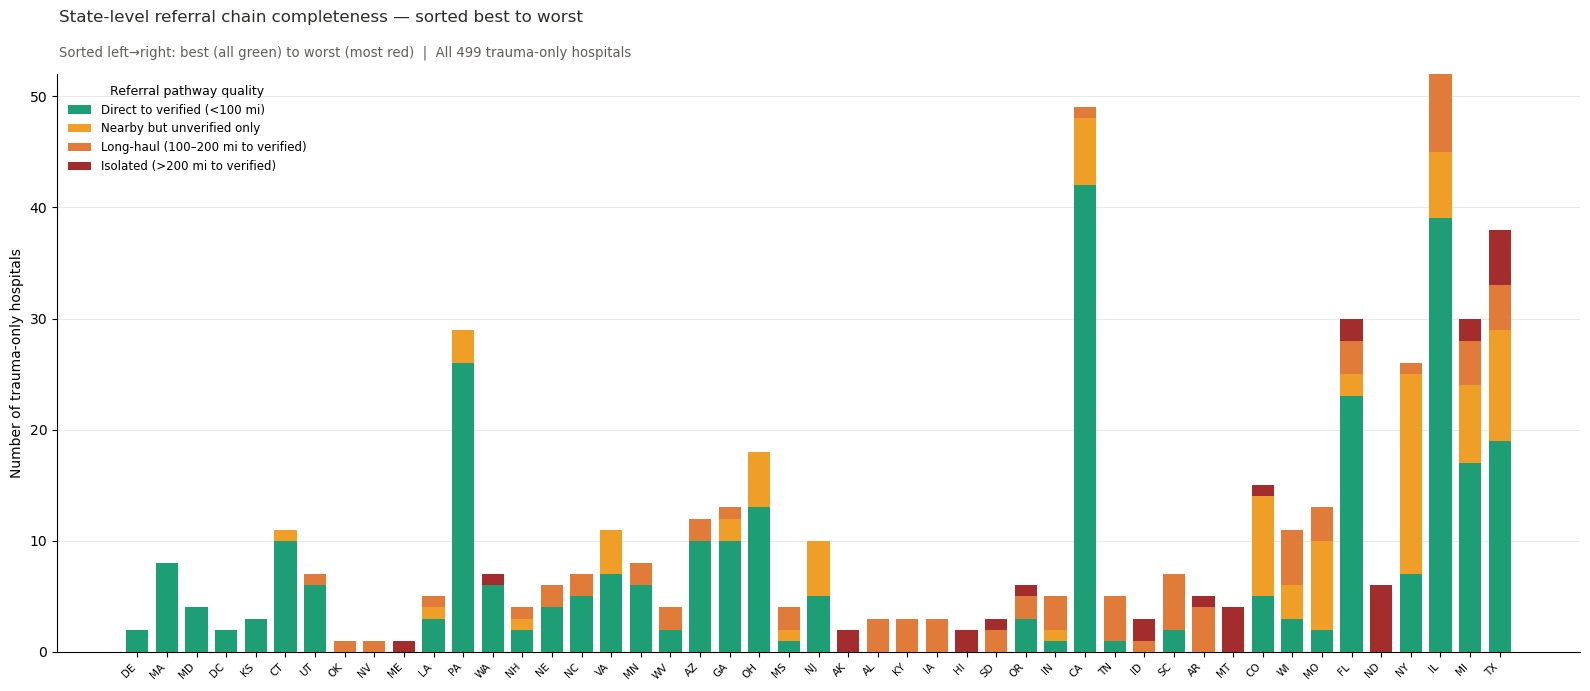

In [38]:
#State referral chain — stacked by pathway quality ───────────────

state_pathway = (
    trauma_only
    .groupby(['STATE', 'pathway_class'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in pathway_order:
    if col not in state_pathway.columns:
        state_pathway[col] = 0

# Risk score: isolated=3, long-haul=2, unverified=1, direct=0
state_pathway['chain_risk_score'] = (
    state_pathway['Isolated (>200 mi to verified)']     * 3 +
    state_pathway['Long-haul (100–200 mi to verified)'] * 2 +
    state_pathway['Nearby but unverified only']         * 1
)
state_pathway = state_pathway.sort_values('chain_risk_score', ascending=True)

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x      = np.arange(len(state_pathway))
bottom = np.zeros(len(state_pathway))

for col, color in zip(pathway_order, pathway_colors_list):
    vals = state_pathway[col].values
    ax.bar(x, vals, bottom=bottom, color=color, width=0.75, label=col, zorder=3)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(state_pathway['STATE'], fontsize=7.5, rotation=45, ha='right')
ax.set_ylabel('Number of trauma-only hospitals', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.5, zorder=0)
ax.legend(fontsize=8.5, frameon=False, loc='upper left',
          title='Referral pathway quality', title_fontsize=9)

fig.text(0.04, 0.98,
         'State-level referral chain completeness — sorted best to worst',
         fontsize=12, fontweight='500', color='#2C2C2A', va='top')
fig.text(0.04, 0.93,
         'Sorted left→right: best (all green) to worst (most red)  |  All 499 trauma-only hospitals',
         fontsize=9.5, color='#5F5E5A', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

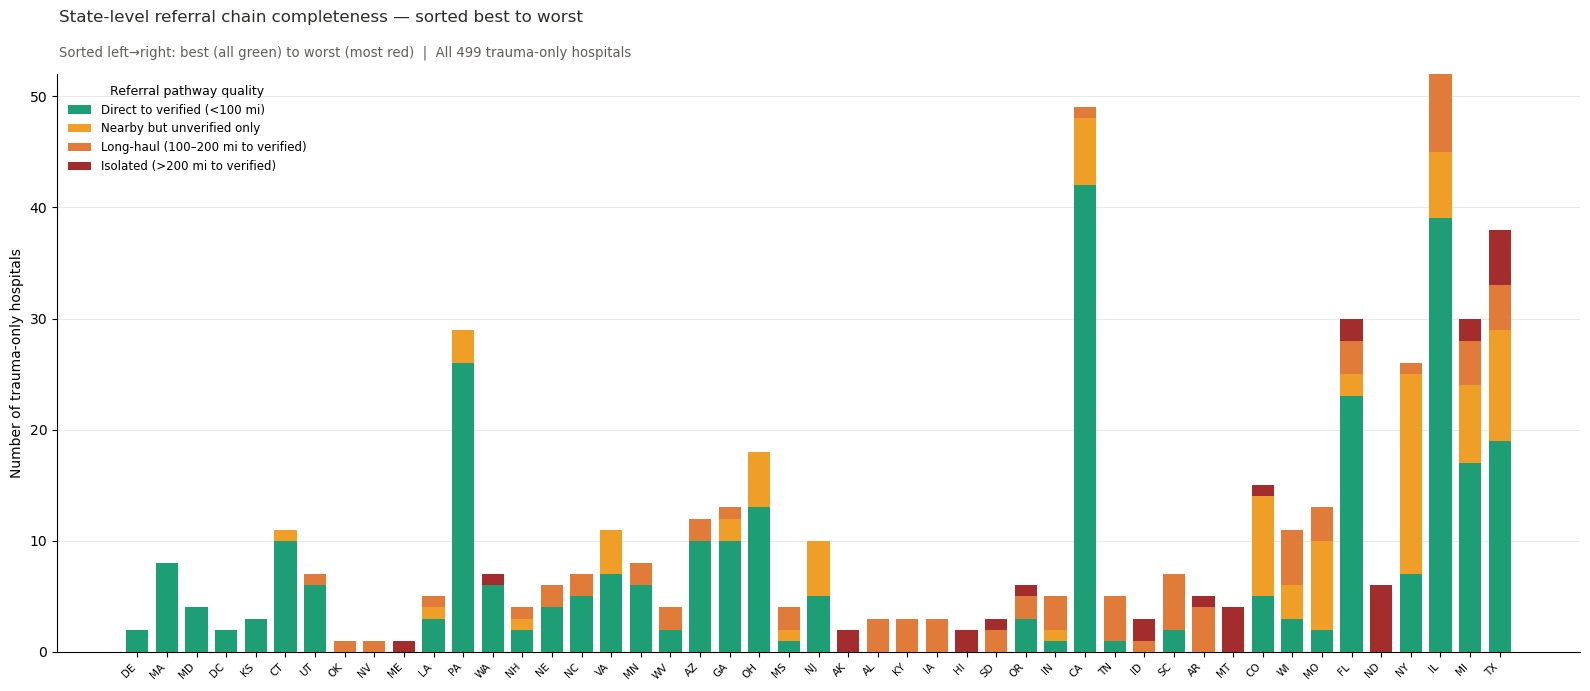

Chart done.


In [39]:
# ── Chart 5c: State referral chain — stacked by pathway quality ───────────────

state_pathway = (
    trauma_only
    .groupby(['STATE', 'pathway_class'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in pathway_order:
    if col not in state_pathway.columns:
        state_pathway[col] = 0

state_pathway['chain_risk_score'] = (
    state_pathway['Isolated (>200 mi to verified)']     * 3 +
    state_pathway['Long-haul (100–200 mi to verified)'] * 2 +
    state_pathway['Nearby but unverified only']         * 1
)
state_pathway = state_pathway.sort_values('chain_risk_score', ascending=True)

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x      = np.arange(len(state_pathway))
bottom = np.zeros(len(state_pathway))

for col, color in zip(pathway_order, pathway_colors_list):
    vals = state_pathway[col].values
    ax.bar(x, vals, bottom=bottom, color=color, width=0.75, label=col, zorder=3)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(state_pathway['STATE'], fontsize=7.5, rotation=45, ha='right')
ax.set_ylabel('Number of trauma-only hospitals', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.5, zorder=0)
ax.legend(fontsize=8.5, frameon=False, loc='upper left',
          title='Referral pathway quality', title_fontsize=9)

fig.text(0.04, 0.98,
         'State-level referral chain completeness — sorted best to worst',
         fontsize=12, fontweight='500', color='#2C2C2A', va='top')
fig.text(0.04, 0.93,
         'Sorted left→right: best (all green) to worst (most red)  |  All 499 trauma-only hospitals',
         fontsize=9.5, color='#5F5E5A', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()
print('Chart done.')

In [40]:
# ── Decision-support referral model ───────────────────────────────────────────
# For each trauma-only hospital, simulates what a referral decision-support
# tool would output: where to send, how far, urgency, peds capability
# All based on structural proxies — no patient data needed

# We need burn bed info on the verified centers for destination context
burn_verified = data_df[data_df['is_nationally_verified']].copy()
burn_any      = data_df[data_df['is_burn']].copy()
burn_peds_df  = data_df[data_df['is_burn_peds']].copy()

def urgency_flag(dist_verified, quality_gap, state_pressure):
    """
    HIGH   : isolated (>200 mi) OR no verified center in state
    MEDIUM : long-haul (100-200 mi) OR quality gap > 50 mi
    LOW    : direct access to verified center within 100 mi
    """
    if dist_verified > 200 or state_pressure > 6:
        return 'HIGH'
    elif dist_verified > 100 or quality_gap > 50:
        return 'MEDIUM'
    else:
        return 'LOW'

# State pressure lookup from earlier
pressure_lookup = pressure.set_index('STATE')['referral_pressure_ratio'].to_dict()

rows = []
for _, hosp in trauma_only.iterrows():

    # ── Nearest verified adult burn center ────────────────────────────────────
    nearest_verified_name = hosp['nearest_verified_center']
    dist_verified         = hosp['miles_to_nearest_verified']
    dist_any              = hosp['miles_to_nearest_burn']
    quality_gap           = hosp['quality_gap_miles']

    # ── Nearest peds burn center ──────────────────────────────────────────────
    # compute on the fly from peds_burn_geo
    if len(peds_burn_geo) > 0:
        d_peds = haversine_miles(hosp['lat'], hosp['lon'],
                                 peds_burn_geo['lat'].values,
                                 peds_burn_geo['lon'].values)
        idx_p             = np.argmin(d_peds)
        nearest_peds_name = peds_burn_geo.iloc[idx_p]['HOSPITAL_NAME']
        dist_peds         = round(d_peds[idx_p], 1)
    else:
        nearest_peds_name = 'None available'
        dist_peds         = np.nan

    # ── State pressure ────────────────────────────────────────────────────────
    state_pressure = pressure_lookup.get(hosp['STATE'], 0)

    # ── Urgency ───────────────────────────────────────────────────────────────
    urgency = urgency_flag(dist_verified, quality_gap, state_pressure)

    # ── Referral recommendation ───────────────────────────────────────────────
    if quality_gap == 0:
        recommendation = f"Refer to {nearest_verified_name} ({dist_verified:.0f} mi) — verified"
    else:
        recommendation = (f"Nearest burn: {hosp['nearest_burn_center'][:35]} ({dist_any:.0f} mi, unverified) | "
                          f"Nearest verified: {nearest_verified_name[:35]} ({dist_verified:.0f} mi)")

    rows.append({
        'HOSPITAL_NAME':           hosp['HOSPITAL_NAME'],
        'STATE':                   hosp['STATE'],
        'CITY':                    hosp['CITY'],
        'is_l1_trauma':            hosp['is_l1_trauma'],
        'is_l2_trauma':            hosp['is_l2_trauma'],
        'miles_to_nearest_burn':   dist_any,
        'miles_to_nearest_verified': dist_verified,
        'quality_gap_miles':       quality_gap,
        'nearest_verified_center': nearest_verified_name,
        'nearest_peds_burn':       nearest_peds_name,
        'miles_to_nearest_peds':   dist_peds,
        'state_pressure_ratio':    state_pressure,
        'urgency_flag':            urgency,
        'pathway_class':           hosp['pathway_class'],
        'referral_recommendation': recommendation,
    })

referral_model = pd.DataFrame(rows)

print(f'Referral model built for {len(referral_model)} trauma-only hospitals')
print()
print('=== Urgency Distribution ===')
for flag in ['HIGH', 'MEDIUM', 'LOW']:
    n = (referral_model['urgency_flag'] == flag).sum()
    print(f'  {flag:<8} {n:>4}  ({n/len(referral_model)*100:.1f}%)')

print()
print('=== Sample HIGH urgency cases ===')
high = referral_model[referral_model['urgency_flag'] == 'HIGH'].sort_values(
    'miles_to_nearest_verified', ascending=False
).head(10)
for _, r in high.iterrows():
    l = 'L1' if r['is_l1_trauma'] else 'L2'
    print(f"  [{l}] {r['HOSPITAL_NAME'][:45]:<45} ({r['STATE']})  "
          f"{r['miles_to_nearest_verified']:.0f} mi to verified")

Referral model built for 499 trauma-only hospitals

=== Urgency Distribution ===
  HIGH      157  (31.5%)
  MEDIUM     63  (12.6%)
  LOW       279  (55.9%)

=== Sample HIGH urgency cases ===
  [L2] Tripler Army Medical Center                   (HI)  2396 mi to verified
  [L1] The Queen's Medical Center                    (HI)  2394 mi to verified
  [L2] Alaska Native Medical Center                  (AK)  1432 mi to verified
  [L2] Providence Alaska Medical Center/Children's H (AK)  1432 mi to verified
  [L2] Benefis Hospitals                             (MT)  465 mi to verified
  [L2] Trinity Health                                (ND)  443 mi to verified
  [L2] Providence St. Patrick Hospital               (MT)  393 mi to verified
  [L2] Billings Clinic                               (MT)  385 mi to verified
  [L2] SCL Health - St. Vincent Healthcare           (MT)  384 mi to verified
  [L2] Sanford Medical Center                        (ND)  383 mi to verified


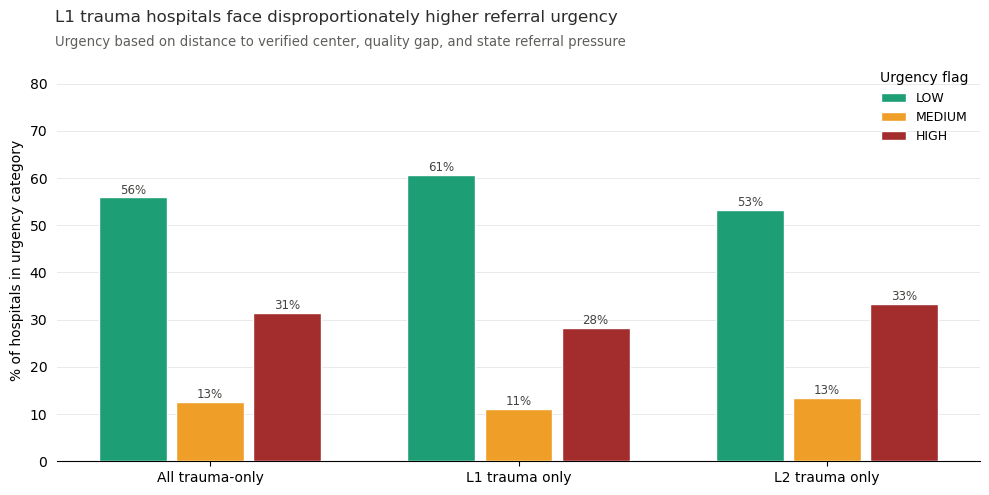

In [41]:
# ── Chart 6a: Urgency distribution — L1 vs L2 vs all ─────────────────────────

urgency_order  = ['LOW', 'MEDIUM', 'HIGH']
urgency_colors = ['#1D9E75', '#EF9F27', '#A32D2D']

groups = {
    'All trauma-only':  referral_model,
    'L1 trauma only':   referral_model[referral_model['is_l1_trauma']],
    'L2 trauma only':   referral_model[referral_model['is_l2_trauma']],
}

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x       = np.arange(len(groups))
width   = 0.25
offsets = [-width, 0, width]

for i, (urgency, color) in enumerate(zip(urgency_order, urgency_colors)):
    vals = [(df['urgency_flag'] == urgency).sum() / len(df) * 100
            for df in groups.values()]
    bars = ax.bar(x + offsets[i], vals, width=width - 0.03,
                  color=color, label=urgency, zorder=3, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{v:.0f}%', ha='center', fontsize=8.5, color='#444441')

ax.set_xticks(x)
ax.set_xticklabels(groups.keys(), fontsize=10)
ax.set_ylabel('% of hospitals in urgency category', fontsize=10)
ax.set_ylim(0, 85)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.5, zorder=0)
ax.legend(title='Urgency flag', fontsize=9, frameon=False)

fig.text(0.06, 0.98,
         'L1 trauma hospitals face disproportionately higher referral urgency',
         fontsize=12, fontweight='500', color='#2C2C2A', va='top')
fig.text(0.06, 0.93,
         'Urgency based on distance to verified center, quality gap, and state referral pressure',
         fontsize=9.5, color='#5F5E5A', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

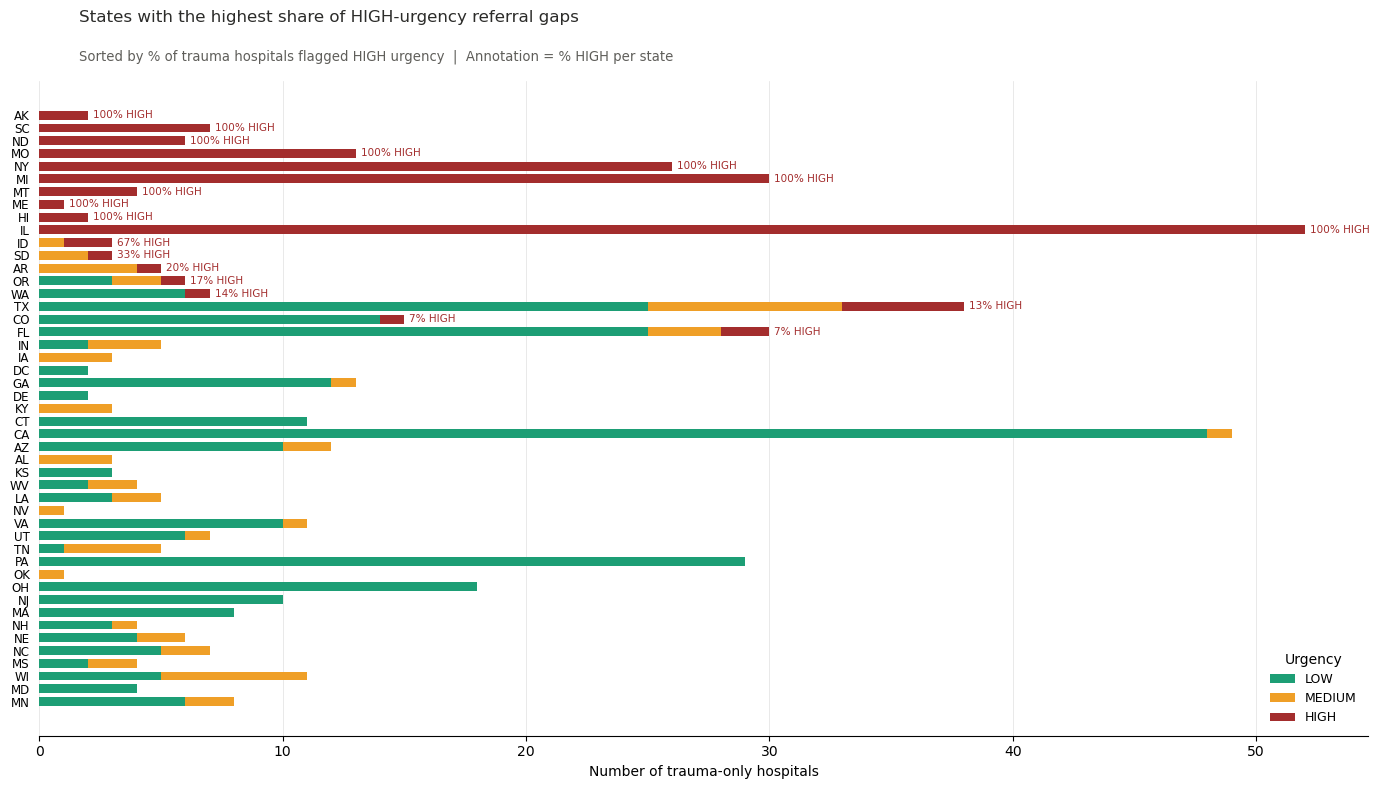

In [42]:
#Chart 6b: HIGH urgency hospitals per state 

state_urgency = (
    referral_model
    .groupby(['STATE', 'urgency_flag'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ['LOW', 'MEDIUM', 'HIGH']:
    if col not in state_urgency.columns:
        state_urgency[col] = 0

state_urgency['total']    = state_urgency[['LOW','MEDIUM','HIGH']].sum(axis=1)
state_urgency['pct_high'] = (state_urgency['HIGH'] / state_urgency['total'] * 100).round(1)
state_urgency = state_urgency[state_urgency['total'] > 0].sort_values('pct_high', ascending=True)

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

y      = np.arange(len(state_urgency))
bottom = np.zeros(len(state_urgency))

for col, color in zip(['LOW', 'MEDIUM', 'HIGH'], urgency_colors):
    vals = state_urgency[col].values
    ax.barh(y, vals, left=bottom, color=color, height=0.7,
            label=col, zorder=3)
    bottom += vals

# Annotate pct HIGH on right
for i, (_, row) in enumerate(state_urgency.iterrows()):
    if row['pct_high'] > 0:
        ax.text(row['total'] + 0.2, i,
                f"{row['pct_high']:.0f}% HIGH",
                va='center', fontsize=7.5, color='#A32D2D')

ax.set_yticks(y)
ax.set_yticklabels(state_urgency['STATE'], fontsize=8.5)
ax.set_xlabel('Number of trauma-only hospitals', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis='x', color='#e0e0e0', linewidth=0.5, zorder=0)
ax.legend(title='Urgency', fontsize=9, frameon=False, loc='lower right')

fig.text(0.06, 0.98,
         'States with the highest share of HIGH-urgency referral gaps',
         fontsize=12, fontweight='500', color='#2C2C2A', va='top')
fig.text(0.06, 0.93,
         'Sorted by % of trauma hospitals flagged HIGH urgency  |  Annotation = % HIGH per state',
         fontsize=9.5, color='#5F5E5A', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

In [43]:
# ── Simulated decision-support tool output — sample hospital cards ─────────────
# This is what the tool would show a clinician at point of care

print('=' * 75)
print('  BURN REFERRAL DECISION SUPPORT — SAMPLE OUTPUT')
print('  Structural proxy model | Source: NIRD data')
print('=' * 75)

sample = pd.concat([
    referral_model[referral_model['urgency_flag'] == 'HIGH'].head(3),
    referral_model[referral_model['urgency_flag'] == 'MEDIUM'].head(2),
    referral_model[referral_model['urgency_flag'] == 'LOW'].head(2),
])

for _, r in sample.iterrows():
    flag_display = {
        'HIGH':   '🔴 HIGH URGENCY',
        'MEDIUM': '🟡 MEDIUM URGENCY',
        'LOW':    '🟢 LOW URGENCY'
    }[r['urgency_flag']]

    level = 'Level 1' if r['is_l1_trauma'] else 'Level 2'

    print(f"\n  {flag_display}")
    print(f"  Hospital : {r['HOSPITAL_NAME']}")
    print(f"  Location : {r['CITY']}, {r['STATE']}  |  Trauma level: {level}")
    print(f"  Pathway  : {r['pathway_class']}")
    print(f"  ── Adult burn referral ──────────────────────────────────")
    print(f"  Nearest verified : {r['nearest_verified_center'][:55]}")
    print(f"  Distance         : {r['miles_to_nearest_verified']:.0f} miles")
    if r['quality_gap_miles'] > 0:
        print(f"  ⚠️  Closer unverified center exists — quality gap: {r['quality_gap_miles']:.0f} mi extra to reach verified")
    print(f"  ── Pediatric burn referral ──────────────────────────────")
    print(f"  Nearest peds     : {r['nearest_peds_burn'][:55]}")
    print(f"  Distance         : {r['miles_to_nearest_peds']:.0f} miles")
    print(f"  State pressure   : {r['state_pressure_ratio']:.1f} trauma hospitals per verified center")
    print(f"  {'-' * 65}")

  BURN REFERRAL DECISION SUPPORT — SAMPLE OUTPUT
  Structural proxy model | Source: NIRD data

  🔴 HIGH URGENCY
  Hospital : Alaska Native Medical Center
  Location : Anchorage, AK  |  Trauma level: Level 2
  Pathway  : Isolated (>200 mi to verified)
  ── Adult burn referral ──────────────────────────────────
  Nearest verified : UW Medicine/Harborview Medical Center (UW Medicine Regi
  Distance         : 1432 miles
  ── Pediatric burn referral ──────────────────────────────
  Nearest peds     : UW Medicine/Harborview Medical Center (UW Medicine Regi
  Distance         : 1432 miles
  State pressure   : 2.0 trauma hospitals per verified center
  -----------------------------------------------------------------

  🔴 HIGH URGENCY
  Hospital : Providence Alaska Medical Center/Children's Hospital at Providence
  Location : Anchorage, AK  |  Trauma level: Level 2
  Pathway  : Isolated (>200 mi to verified)
  ── Adult burn referral ──────────────────────────────────
  Nearest verified : UW Me